# ML from DFT data

- learn form library features
- learn from bop features
- combination of features
- compare different regression methods
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
import glob
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('font', size=18)

from itertools import product

from tqdm.auto import tqdm

# Parameters 

In [2]:
dataset = 'Cr-Co-W'#'Fe-Mo'
system = dataset.replace('-','')
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'ORTHOGONALOS' #, 'ORTHOGONAL', 'CANONICAL','ORTOGONALOS'

# Targets

In [3]:
BSFile = os.path.join(f'{dataset}','FullyCuratedParsedBriefSummary.pkl')
BS = pd.read_pickle(BSFile)

In [4]:
BS[['V','E0','B','EF']]

,V,E0,B,EF
index,,,,
Co_pv6W_sv6.C14-BBA.FM,13.175678 A,-10.000427,293.907391 GPa,-0.008728
Co_pv6W_sv6.C14-BBA.NM,13.175679 A,-10.000427,293.949578 GPa,-0.008728
Cr_pv6W_sv2.D0_19-A3B.FM,13.098145 A,-10.002413,244.993002 GPa,0.36766
Cr_pv6W_sv2.D0_19-A3B.NM,13.093819 A,-10.002452,248.338396 GPa,0.367621
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,13.525828 A,-10.003732,243.415325 GPa,0.322855
...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,13.189913 A,-9.988760,251.071094 GPa,0.27345
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,13.189987 A,-9.988760,251.093896 GPa,0.27345
Co_pv13W_sv16.chi-ABAB.NM,14.051746 A,-9.988843,263.749012 GPa,0.309268


## atomic feature files

In [5]:
pd.read_pickle(f'{dataset}/Descriptors/DatasetFeatures.pkl')

,Structure,Mag,Co_pv,Cr_pv,W_sv,N_CN12,N_CN13,N_CN14,N_CN15,N_CN16,...,Pos_2,Pos_3,Pos_4,Pos_5,Pos_6,Pos_7,Pos_8,Pos_9,Pos_10,Pos_11
Co_pv6W_sv6.C14-BBA.FM,1,0,0.500000,0.000000,0.500000,12.0,0.0,0.0,0.0,16.0,...,3,1,0,0,0,0,0,0,0,0
Co_pv6W_sv6.C14-BBA.NM,1,1,0.500000,0.000000,0.500000,12.0,0.0,0.0,0.0,16.0,...,3,1,0,0,0,0,0,0,0,0
Cr_pv6W_sv2.D0_19-A3B.FM,8,0,0.000000,0.750000,0.250000,12.0,0.0,0.0,0.0,0.0,...,2,2,0,0,0,0,0,0,0,0
Cr_pv6W_sv2.D0_19-A3B.NM,8,1,0.000000,0.750000,0.250000,12.0,0.0,0.0,0.0,0.0,...,2,2,0,0,0,0,0,0,0,0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,10,0,0.133333,0.533333,0.333333,12.0,0.0,14.0,15.0,0.0,...,1,2,2,3,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,10,1,0.066667,0.666667,0.266667,12.0,0.0,14.0,15.0,0.0,...,2,2,3,2,0,0,0,0,0,0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,10,0,0.066667,0.666667,0.266667,12.0,0.0,14.0,15.0,0.0,...,2,2,3,2,0,0,0,0,0,0
Co_pv13W_sv16.chi-ABAB.NM,6,1,0.448276,0.000000,0.551724,12.0,13.0,0.0,0.0,16.0,...,3,1,3,0,0,0,0,0,0,0
Co_pv13W_sv16.chi-ABAB.FM,6,0,0.448276,0.000000,0.551724,12.0,13.0,0.0,0.0,16.0,...,3,1,3,0,0,0,0,0,0,0


In [6]:
DescriptorList = {'atomic' : 'matminer_atomic_features.pkl',
'dataset' : 'DatasetFeatures.pkl',
'Pyscal' : 'CNAVPyscal.pkl',
'Canonical BOP': f'CNAV_parallel_{system}_initial_canonical_table_WUBIND_16.pkl',
'Projections BOP': f'CNAV_parallel_{system}_initial_projections_table_WUBIND_16.pkl',
'Projections OS BOP': f'CNAV_parallel_{system}_initial_projections_os_table_WUBIND_16.pkl',
}

In [7]:
DescriptorFileList = {
    name: os.path.join( f'{dataset}','Descriptors',f'{basename}') for name, basename in DescriptorList.items()
}

In [8]:
Features  = {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [9]:
Features['Projections OS BOP']

,U_bind,U_bond_atom,moments_1_0,moments_1_CN12,moments_1_CN13,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,...,Ainf_1_CN13,Ainf_1_CN14,Ainf_1_CN15,Ainf_1_CN16,Binf_1_0,Binf_1_CN12,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16
Co_pv6W_sv6.C14-BBA.FM,-120.002266,-110.387407,48.106100,38.787267,0.000000,0.000000,0.000000,9.318833,-418.475500,-344.764833,...,0.000000,0.000000,0.00000,-1.754803,3.722262,2.511714,0.000000,0.000000,0.000000,1.210548
Co_pv6W_sv6.C14-BBA.NM,-120.002266,-110.387407,48.106100,38.787267,0.000000,0.000000,0.000000,9.318833,-418.475500,-344.764833,...,0.000000,0.000000,0.00000,-1.754803,3.722262,2.511714,0.000000,0.000000,0.000000,1.210548
Cr_pv6W_sv2.D0_19-A3B.FM,-78.184461,-83.497746,15.702325,15.702325,0.000000,0.000000,0.000000,0.000000,-97.387850,-97.387850,...,0.000000,0.000000,0.00000,0.000000,3.209278,3.209278,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,-78.184461,-83.497746,15.702325,15.702325,0.000000,0.000000,0.000000,0.000000,-97.387850,-97.387850,...,0.000000,0.000000,0.00000,0.000000,3.209278,3.209278,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,-327.881431,-319.802263,25.801240,12.419027,0.000000,11.887720,1.494493,0.000000,-199.532307,-100.562993,...,0.000000,-2.347693,-0.52646,0.000000,4.335802,1.495374,0.000000,2.242107,0.598321,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,-311.423319,-316.000015,20.164293,7.600207,0.000000,11.023553,1.540533,0.000000,-143.288413,-57.440020,...,0.000000,-2.219003,-0.49055,0.000000,3.547238,1.192194,0.000000,1.888829,0.466215,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,-311.423319,-316.000015,20.164293,7.600207,0.000000,11.023553,1.540533,0.000000,-143.288413,-57.440020,...,0.000000,-2.219003,-0.49055,0.000000,3.547238,1.192194,0.000000,1.888829,0.466215,0.000000
Co_pv13W_sv16.chi-ABAB.NM,-344.693837,-324.720823,48.496128,14.412372,27.472552,0.000000,0.000000,6.611203,-429.008310,-131.748414,...,-2.685099,0.000000,0.00000,-0.963261,4.385532,1.864680,1.800631,0.000000,0.000000,0.720221
Co_pv13W_sv16.chi-ABAB.FM,-344.693837,-324.720823,48.496128,14.412372,27.472552,0.000000,0.000000,6.611203,-429.008310,-131.748414,...,-2.685099,0.000000,0.00000,-0.963261,4.385532,1.864680,1.800631,0.000000,0.000000,0.720221


for featurekey, features in Features.items():
    if 'BOP' in featurekey:
        features['shapeFactor_0'] = features.bn_1_0.divide(features.bn_2_0)  

fig, ax  = plt.subplots()
hists = [ax.hist(feature.shapeFactor_0, range=[0.5,1.3], bins=100, label=featurename) for featurename, feature in Features.items() if 'BOP' in featurename]
ax.set_xlabel('$b_1 / b_2$')
ax.legend()

In [10]:
Features['dataset']

,Structure,Mag,Co_pv,Cr_pv,W_sv,N_CN12,N_CN13,N_CN14,N_CN15,N_CN16,...,Pos_2,Pos_3,Pos_4,Pos_5,Pos_6,Pos_7,Pos_8,Pos_9,Pos_10,Pos_11
Co_pv6W_sv6.C14-BBA.FM,1,0,0.500000,0.000000,0.500000,12.0,0.0,0.0,0.0,16.0,...,3,1,0,0,0,0,0,0,0,0
Co_pv6W_sv6.C14-BBA.NM,1,1,0.500000,0.000000,0.500000,12.0,0.0,0.0,0.0,16.0,...,3,1,0,0,0,0,0,0,0,0
Cr_pv6W_sv2.D0_19-A3B.FM,8,0,0.000000,0.750000,0.250000,12.0,0.0,0.0,0.0,0.0,...,2,2,0,0,0,0,0,0,0,0
Cr_pv6W_sv2.D0_19-A3B.NM,8,1,0.000000,0.750000,0.250000,12.0,0.0,0.0,0.0,0.0,...,2,2,0,0,0,0,0,0,0,0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,10,0,0.133333,0.533333,0.333333,12.0,0.0,14.0,15.0,0.0,...,1,2,2,3,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,10,1,0.066667,0.666667,0.266667,12.0,0.0,14.0,15.0,0.0,...,2,2,3,2,0,0,0,0,0,0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,10,0,0.066667,0.666667,0.266667,12.0,0.0,14.0,15.0,0.0,...,2,2,3,2,0,0,0,0,0,0
Co_pv13W_sv16.chi-ABAB.NM,6,1,0.448276,0.000000,0.551724,12.0,13.0,0.0,0.0,16.0,...,3,1,3,0,0,0,0,0,0,0
Co_pv13W_sv16.chi-ABAB.FM,6,0,0.448276,0.000000,0.551724,12.0,13.0,0.0,0.0,16.0,...,3,1,3,0,0,0,0,0,0,0


# Machine Learning 

In [11]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from math import sqrt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor

In [12]:
def score_fitted_model(fittedmodel, xtrain,  xtest, ytrain,ytest):
    predict_train = fittedmodel.predict(xtrain)
    predict_test = fittedmodel.predict(xtest)
    return {'test': mean_squared_error(ytest, predict_test, squared = False), 'train':mean_squared_error(ytrain, predict_train, squared = False)}

# recursion order in BOP features

In [13]:
groups = {'moments':'^moments_.*0$','normed_moments':'^normed.*0', 'recursion coeficients':'an_.*0$|bn_.*0$',
         'sigmas':'sigma.*_0'}

In [14]:
key = 'Canonical BOP'
thisgroup = 'moments'

In [15]:
RMSE = {}

In [16]:
from itertools import product

In [17]:
('Canonical BOP', 'moments') in RMSE.keys()

False

In [18]:
for (group, regex), (featurename, features) in product(groups.items(), Features.items()):
    if 'BOP' not in featurename:
        continue
    if (featurename, group) in RMSE.keys():
        continue
    X = features.filter(regex=regex)
    model = RandomForestRegressor(random_state=42, max_depth = 20)
    xtrain, xtest, ytrain, ytest = train_test_split(X, BS['EF'][X.index], random_state=42)
    model.fit(xtrain, ytrain)
    RMSE[(featurename, group)] = score_fitted_model(model, xtrain, xtest, ytrain, ytest)
dfRMSE = pd.DataFrame.from_dict(RMSE, orient='index').sort_values(by='test')

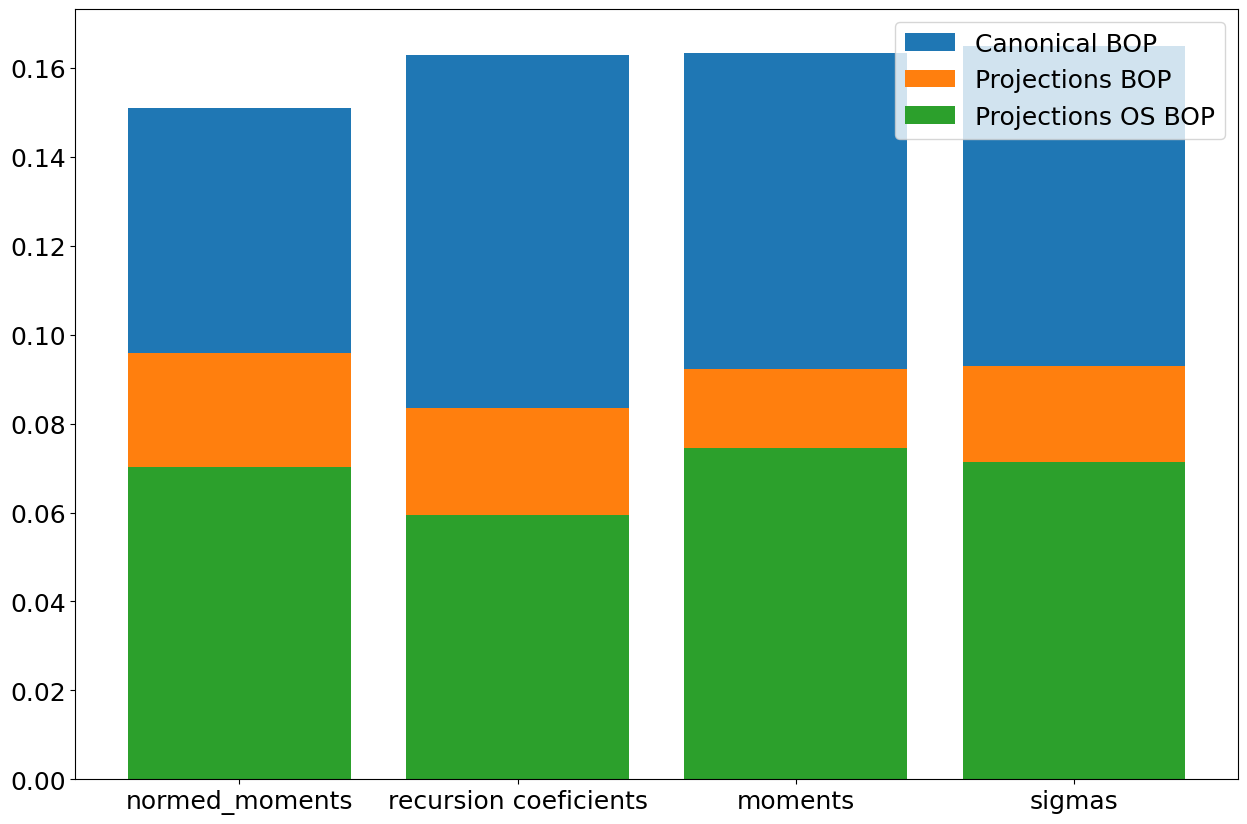

In [19]:
fig, ax = plt.subplots()
colors = {'Canonical BOP': 'Blues',  'Projections BOP': 'greens', 'Projections OS BOP': ['green', 'ocean']}
for group, scores  in dfRMSE.groupby(level=0):
    ax.bar(scores.index.get_level_values(1), scores['test'], label=group)
ax.legend()

In [20]:
RMSE_recursive = {}

In [ ]:
Featur

In [21]:
for (group, regex), (featurename, features) in product(groups.items(), Features.items()):
    if 'BOP' not in featurename:
        continue
    if (featurename, group) in RMSE_recursive.keys():
        continue
    X = features.filter(regex=regex)
    if 'recursion' in featurename:
        X = X.loc[:, ~(X == 0).any()]
        pdb.set_trace()
    model = RandomForestRegressor(random_state=42, max_depth = 20)
    xtrain, xtest, ytrain, ytest = train_test_split(X, BS['EF'][X.index], random_state=42)
    for i in range(1,xtrain.shape[1]):
        model.fit(xtrain.iloc[:,:i], ytrain)
        RMSE_recursive[(featurename, group, i)] = score_fitted_model(model, xtrain.iloc[:,:i], xtest.iloc[:,:i], ytrain, ytest)
dfRMSE_recursive = pd.DataFrame.from_dict(RMSE_recursive, orient='index')#.sort_values(by='test')

In [271]:
dfRMSE_recursive.index.get_level_values(0).unique()

Index(['Canonical BOP', 'Projections BOP', 'Projections OS BOP'], dtype='object')

In [313]:
lines = {'Canonical BOP':'red', 'Projections BOP':'blue', 'Projections OS BOP':'green'}
markers = {'moments': 'o-', 'sigmas': 's-', 'normed_moments':'d-', 'recursion coeficients':'^-' }

In [297]:
from matplotlib.lines import Line2D

/tmp/ipykernel_1192/703845096.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot( dfRMSE_recursive.loc[(model, 'moments')]['test'],markers['moments'], label = 'moments', c = thiscolor)
/tmp/ipykernel_1192/703845096.py:8: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot(dfRMSE_recursive.loc[(model, 'sigmas')]['test'],markers['sigmas'], label = 'sigmas', color = thiscolor)
/tmp/ipykernel_1192/703845096.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot(dfRMSE_recursive.loc[(model, 'normed_moments')]['test'],markers['normed_moments'], label = 'normed_moments', color = thiscolor)
/tmp/ipykernel_1192/703845096.py:10: PerformanceWarning: indexing past lexsort depth may impact performance.
  ax.plot(dfRMSE_recursive.loc[(model, 'recursion coeficients')]['test'], markers['recursion coeficients'], label = 'an/bn', color = thiscolor)


Text(0, 0.5, 'RMSE($\\Delta E_f$) @ test')

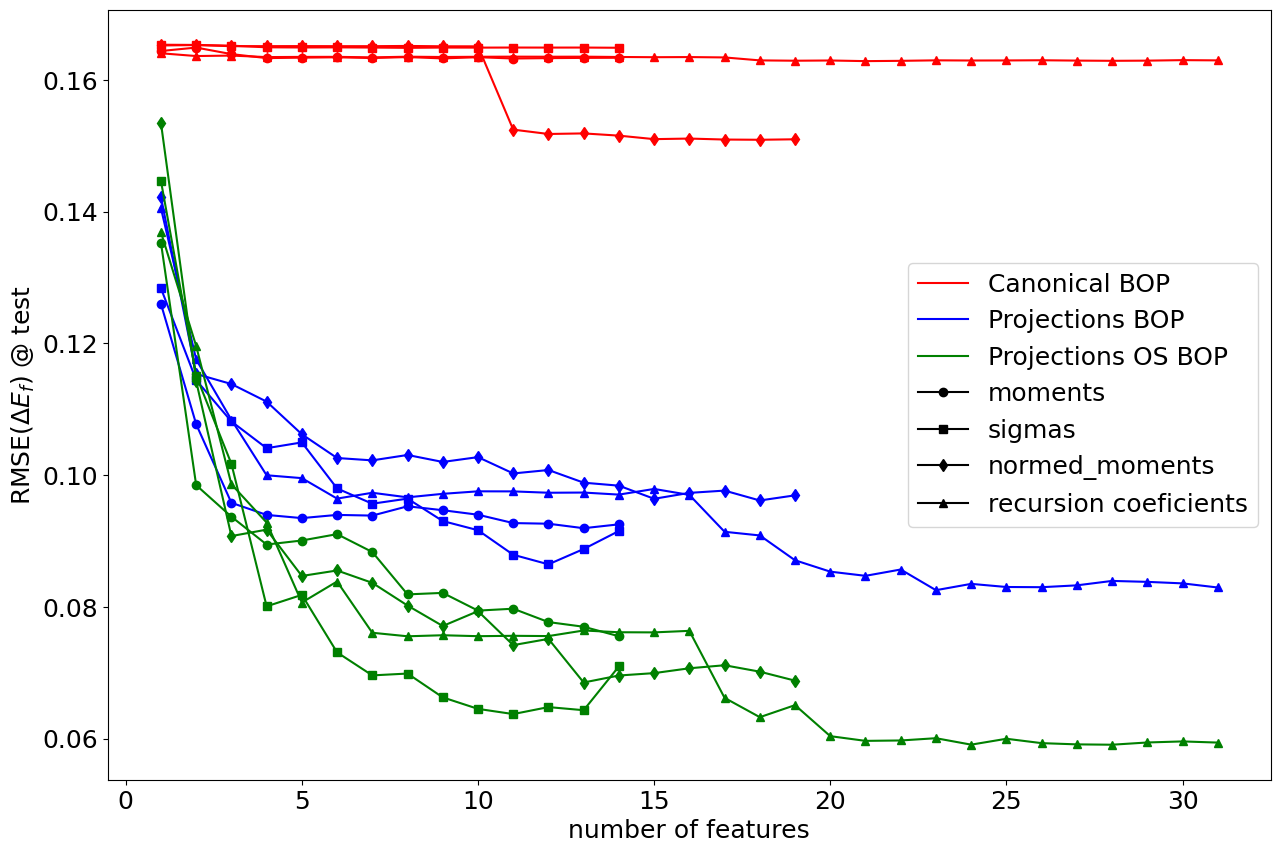

In [326]:
Lines = [] 
fig,ax = plt.subplots()
for model in dfRMSE_recursive.index.get_level_values(0).unique():
    thiscolor = lines[model]
    labels.append(model)
    Lines.append(Line2D([],[],color=thiscolor))
    ax.plot( dfRMSE_recursive.loc[(model, 'moments')]['test'],markers['moments'], label = 'moments', c = thiscolor)
    ax.plot(dfRMSE_recursive.loc[(model, 'sigmas')]['test'],markers['sigmas'], label = 'sigmas', color = thiscolor)
    ax.plot(dfRMSE_recursive.loc[(model, 'normed_moments')]['test'],markers['normed_moments'], label = 'normed_moments', color = thiscolor)
    ax.plot(dfRMSE_recursive.loc[(model, 'recursion coeficients')]['test'], markers['recursion coeficients'], label = 'an/bn', color = thiscolor)
    
    

handles_labels = {key: Line2D([],[],marker=value[0], color='k') for key, value in markers.items()}
lines_labels = {key: Line2D([],[], ls='-', color=value) for key, value in lines.items()}
ax.legend(handles =  list(lines_labels.values())+list(handles_labels.values()), labels=list(lines_labels.keys())+list(handles_labels.keys()) )

ax.set_xlabel('number of features')
ax.set_ylabel('RMSE($\Delta E_f$) @ test')


In [194]:
groupsCN = {'moments':'^moments.*CN.*$','normed_moments':'^normed.*CN.*', 'recursion coeficients':'an.*CN.*|bn.*CN.*',
         'sigmas':'sigma_.*CN.*'}

In [196]:
Features['Canonical BOP'].filter(regex=groupsCN['moments'])

,moments_1_CN12,moments_1_CN13,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_CN12,moments_2_CN13,moments_2_CN14,moments_2_CN15,moments_2_CN16,...,moments_14_CN12,moments_14_CN13,moments_14_CN14,moments_14_CN15,moments_14_CN16,moments_15_CN12,moments_15_CN13,moments_15_CN14,moments_15_CN15,moments_15_CN16
Co_pv6W_sv6.C14-BBA.FM,2.061708,0.000000,0.000000,0.000000,0.434697,-0.745905,0.000000,0.000000,0.000000,-0.211402,...,-2.839175e+06,0.000000,0.00,0.000000,-76123.333333,1.197297e+07,0.000000,0.000000,0.000000,276953.666667
Co_pv6W_sv6.C14-BBA.NM,2.061708,0.000000,0.000000,0.000000,0.434697,-0.745905,0.000000,0.000000,0.000000,-0.211402,...,-2.839175e+06,0.000000,0.00,0.000000,-76123.333333,1.197297e+07,0.000000,0.000000,0.000000,276953.666667
Cr_pv6W_sv2.D0_19-A3B.FM,1.530625,0.000000,0.000000,0.000000,0.000000,-0.453207,0.000000,0.000000,0.000000,0.000000,...,-2.814170e+04,0.000000,0.00,0.000000,0.000000,7.343553e+04,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,1.530625,0.000000,0.000000,0.000000,0.000000,-0.453207,0.000000,0.000000,0.000000,0.000000,...,-2.814170e+04,0.000000,0.00,0.000000,0.000000,7.343553e+04,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.572043,0.000000,1.006888,0.218897,0.000000,-0.188476,0.000000,-0.320610,-0.068624,0.000000,...,-8.544279e+03,0.000000,-19241.00,-1983.346667,0.000000,2.517693e+04,0.000000,75061.313333,5621.693333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.590231,0.000000,0.929313,0.194163,0.000000,-0.187049,0.000000,-0.288361,-0.062231,0.000000,...,-8.820756e+03,0.000000,-10833.22,-1127.262667,0.000000,3.472024e+04,0.000000,34356.973333,3073.280000,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.590231,0.000000,0.929313,0.194163,0.000000,-0.187049,0.000000,-0.288361,-0.062231,0.000000,...,-8.820756e+03,0.000000,-10833.22,-1127.262667,0.000000,3.472024e+04,0.000000,34356.973333,3073.280000,0.000000
Co_pv13W_sv16.chi-ABAB.NM,1.137087,0.838303,0.000000,0.000000,0.266543,-0.325512,-0.306254,0.000000,0.000000,-0.120221,...,-7.203807e+04,-36941.296552,0.00,0.000000,-9545.882759,2.235546e+05,106665.103448,0.000000,0.000000,27164.344828
Co_pv13W_sv16.chi-ABAB.FM,1.137087,0.838303,0.000000,0.000000,0.266543,-0.325512,-0.306254,0.000000,0.000000,-0.120221,...,-7.203807e+04,-36941.296552,0.00,0.000000,-9545.882759,2.235546e+05,106665.103448,0.000000,0.000000,27164.344828


In [118]:
dfRMSE.xs('Projections BOP')


,test,train
recursion coeficients,0.079837,0.035280
sigmas,0.082434,0.035362
normed_moments,0.101735,0.038817
moments,0.102422,0.041765


<AxesSubplot:>

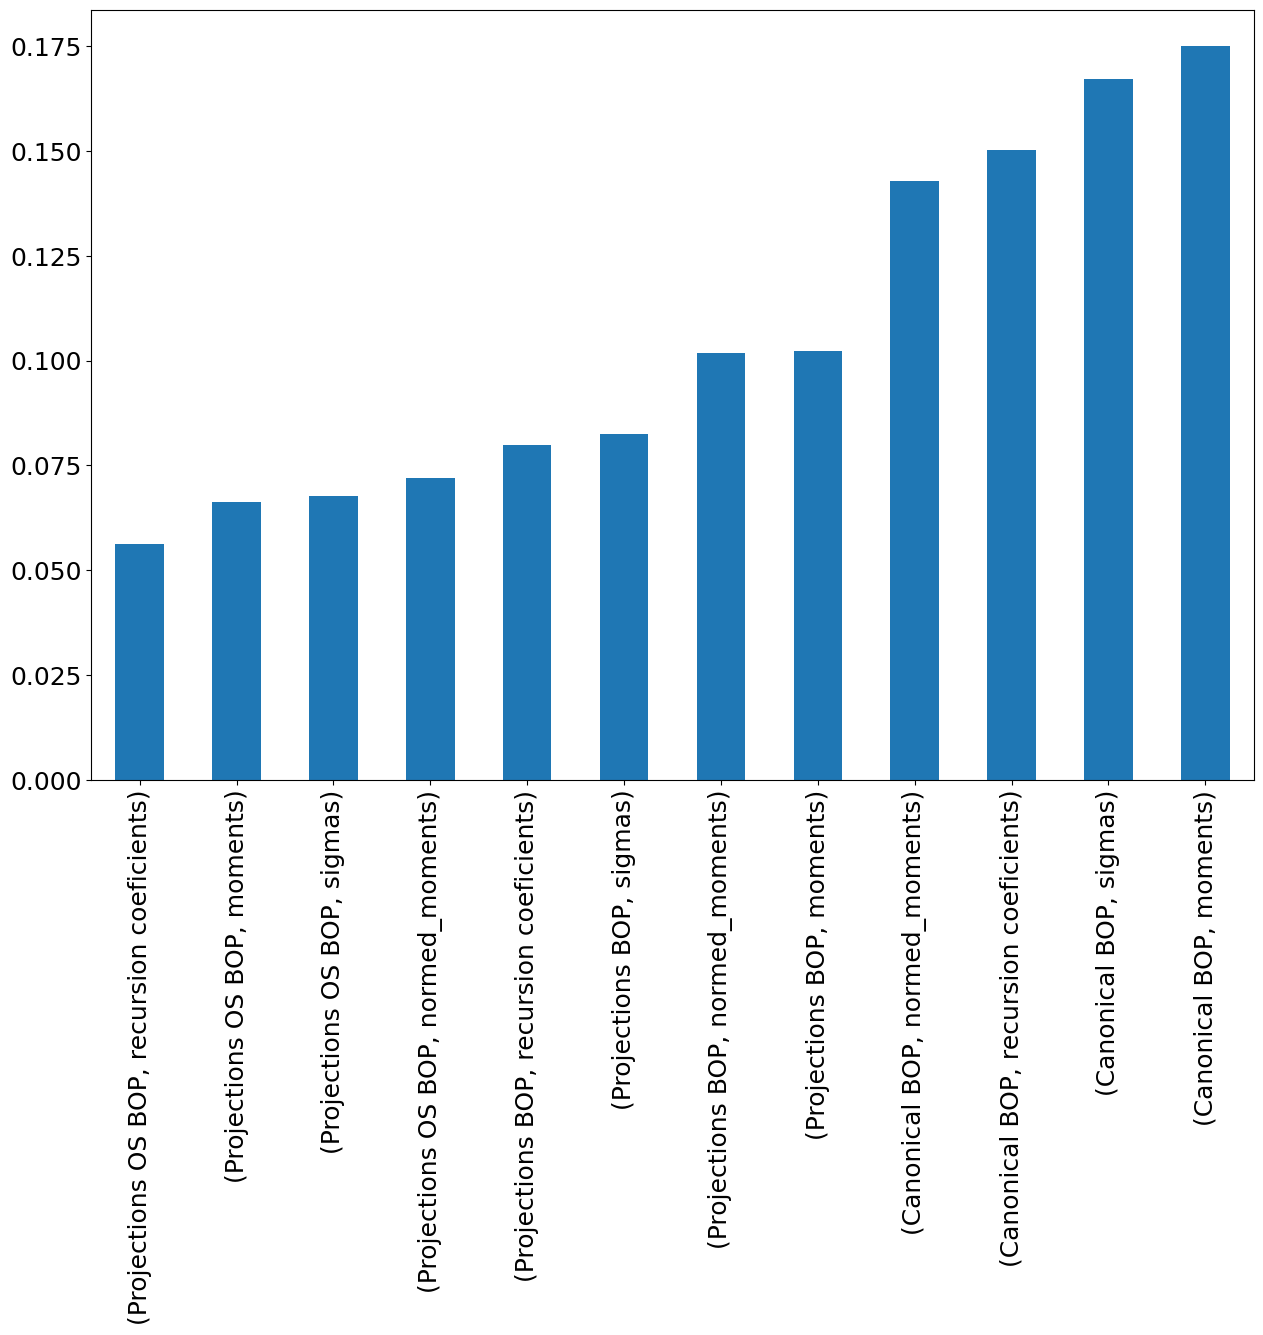

In [110]:
dfRMSE['test'].plot(kind = 'bar')

the target should be a param of the notebook and the BOP models

In [12]:
target = 'EF'

In [13]:
#with open('modelmoreinner.pkl', 'rb') as pkl:
#    saved_model = pickle.load(pkl)

In [14]:
params = {
   'Decision Tree Regressor': {
       'regressor__max_depth': list(np.arange(8,14)), 
       'regressor__max_leaf_nodes': [None], 
       'regressor__random_state':[42] ,
   },
#   'Gradient Boosting Regressor': {}, #{'regressor__criterion': 'squared_error','regressor__n_estimators':10},,
   'Random Forest Regressor': { 'regressor__n_estimators':[10, 20, 50, 100]},
   'Gaussian Process Regressor': {},
   'Multi Level Perceptron':{
#       'regressor__alpha': 0.01,
#       'regressor__learning_rate': 'adaptive',
#       'regressor__learning_rate_init': 0.001,
#       'regressor__activation' :  'logistic',
#       'regressor__hidden_layer_sizes': (33,3),
#       'regressor__solver': 'lbfgs',
   },
}

models = {
   'Decision Tree Regressor':  Pipeline([('regressor', DecisionTreeRegressor())]),
#   'Gradient Boosting Regressor': Pipeline([('regressor',GradientBoostingRegressor())]), 
   'Random Forest Regressor' : Pipeline([('regressor',RandomForestRegressor())]), 
#   'Multi Level Perceptron': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
}
trainedmodels = {}

In [15]:
combis = product(models.items(),  Features.items())
Y = BS[target]#[X.index]
# RMSE={name:{} for name in Features.keys()}
RMSE = {}
gridsearch = {}
BestEstimators = {}
for (modelname, model), (name, thisfeature) in tqdm(combis, total = len(models)*len(Features)):
    intersectindex  = Y.index.intersection(thisfeature.index)
    if 'BOP' in name:
        X = thisfeature.filter(regex='_0$')
    else:
        X = thisfeature.loc[intersectindex]
    thisY = Y.loc[intersectindex]
    xtrain, xtest, ytrain, ytest = train_test_split(X, thisY, test_size=0.2, shuffle=True, random_state=42)
    gridsearch[(modelname, name)] = GridSearchCV(model, param_grid=params[modelname], scoring='neg_root_mean_squared_error')
    gridsearch[(modelname, name)].fit(xtrain, ytrain)# , **fit_params[modelname])
    BestEstimators[(modelname, name)] = gridsearch[(modelname, name)].best_estimator_
    Ypredict = gridsearch[(modelname, name)].predict(xtrain)
    Ypredicttest = gridsearch[(modelname, name)].predict(xtest)
    RMSE[(modelname, name)] = {'train': mean_squared_error(ytrain, Ypredict, squared=False), 'test' : mean_squared_error(ytest, Ypredicttest, squared=False)}

  0%|          | 0/12 [00:00<?, ?it/s]

# Feature accumulation

In [16]:
combis = product(models.items(),  Features.items())
Y = BS[target]#[X.index]

# RMSE={name:{} for name in Features.keys()}
for (modelname, model), (name, thisfeature) in tqdm(combis, total = len(models)*len(Features)):
    if 'BOP' not in name:
        continue
    thisfeaturesname = 'dataset + '+name
    intersectindex  = Y.index.intersection(thisfeature.index)
    x = thisfeature.loc[intersectindex].filter(regex='_0$')
    X = pd.concat([x, Features['dataset']], axis=1)
    X.dropna(inplace=True)
    thisY = Y.loc[intersectindex]
    xtrain, xtest, ytrain, ytest = train_test_split(X, thisY, test_size=0.2, shuffle=True, random_state=42)
    gridsearch[(modelname, thisfeaturesname)] = GridSearchCV(model, param_grid=params[modelname], scoring='neg_root_mean_squared_error')
    gridsearch[(modelname, thisfeaturesname)].fit(xtrain, ytrain)# , **fit_params[modelname])
    BestEstimators[(modelname, thisfeaturesname)] = gridsearch[(modelname, name)].best_estimator_
    Ypredict = gridsearch[(modelname, thisfeaturesname)].predict(xtrain)
    Ypredicttest = gridsearch[(modelname, thisfeaturesname)].predict(xtest)
    RMSE[(modelname, 'dataset + ' + name)] = {'train': mean_squared_error(ytrain, Ypredict, squared=False), 'test' : mean_squared_error(ytest, Ypredicttest, squared=False)}

  0%|          | 0/12 [00:00<?, ?it/s]

In [17]:
dfRMSE = pd.DataFrame.from_dict(RMSE, orient='index')
dfRMSE.sort_values(by='test', inplace=True, ascending=False)

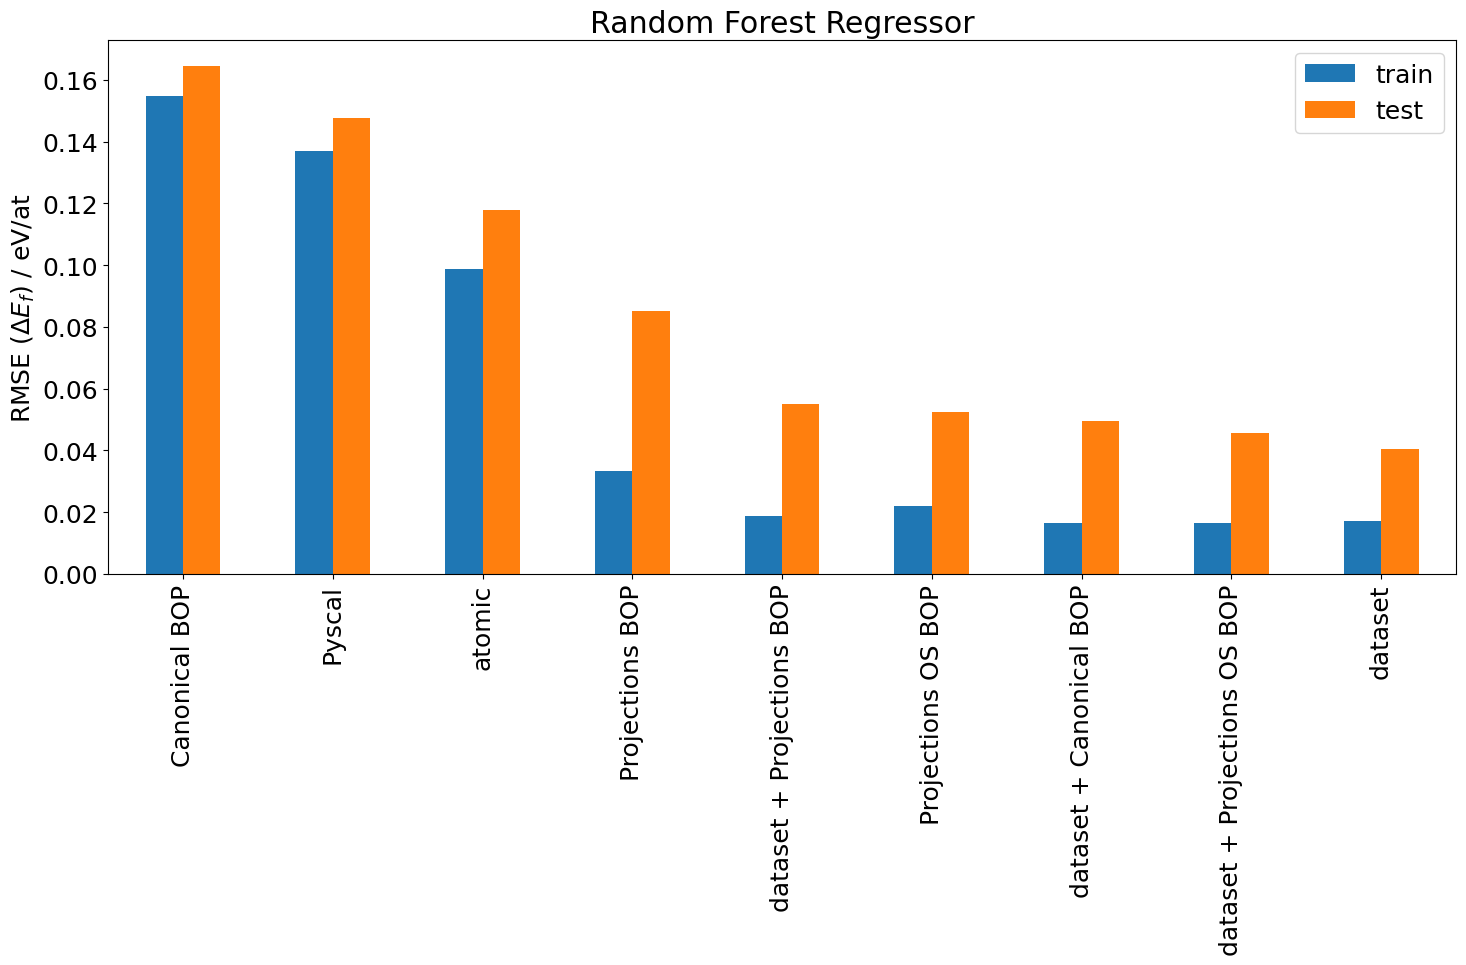

In [18]:
modelname = 'Random Forest Regressor'
ax = dfRMSE.loc[modelname].plot(kind = 'bar', )
ax.set_title(modelname)
ax.set_ylabel('RMSE ($\Delta E_f$) / eV/at')
plt.tight_layout()
plt.savefig('Error_vs_domainKnowledge.pdf')

In [19]:
sorted = dfRMSE['test'].unstack(level=0).sort_values(by='Decision Tree Regressor')

Text(0, 0.5, 'RMSE @ test set')

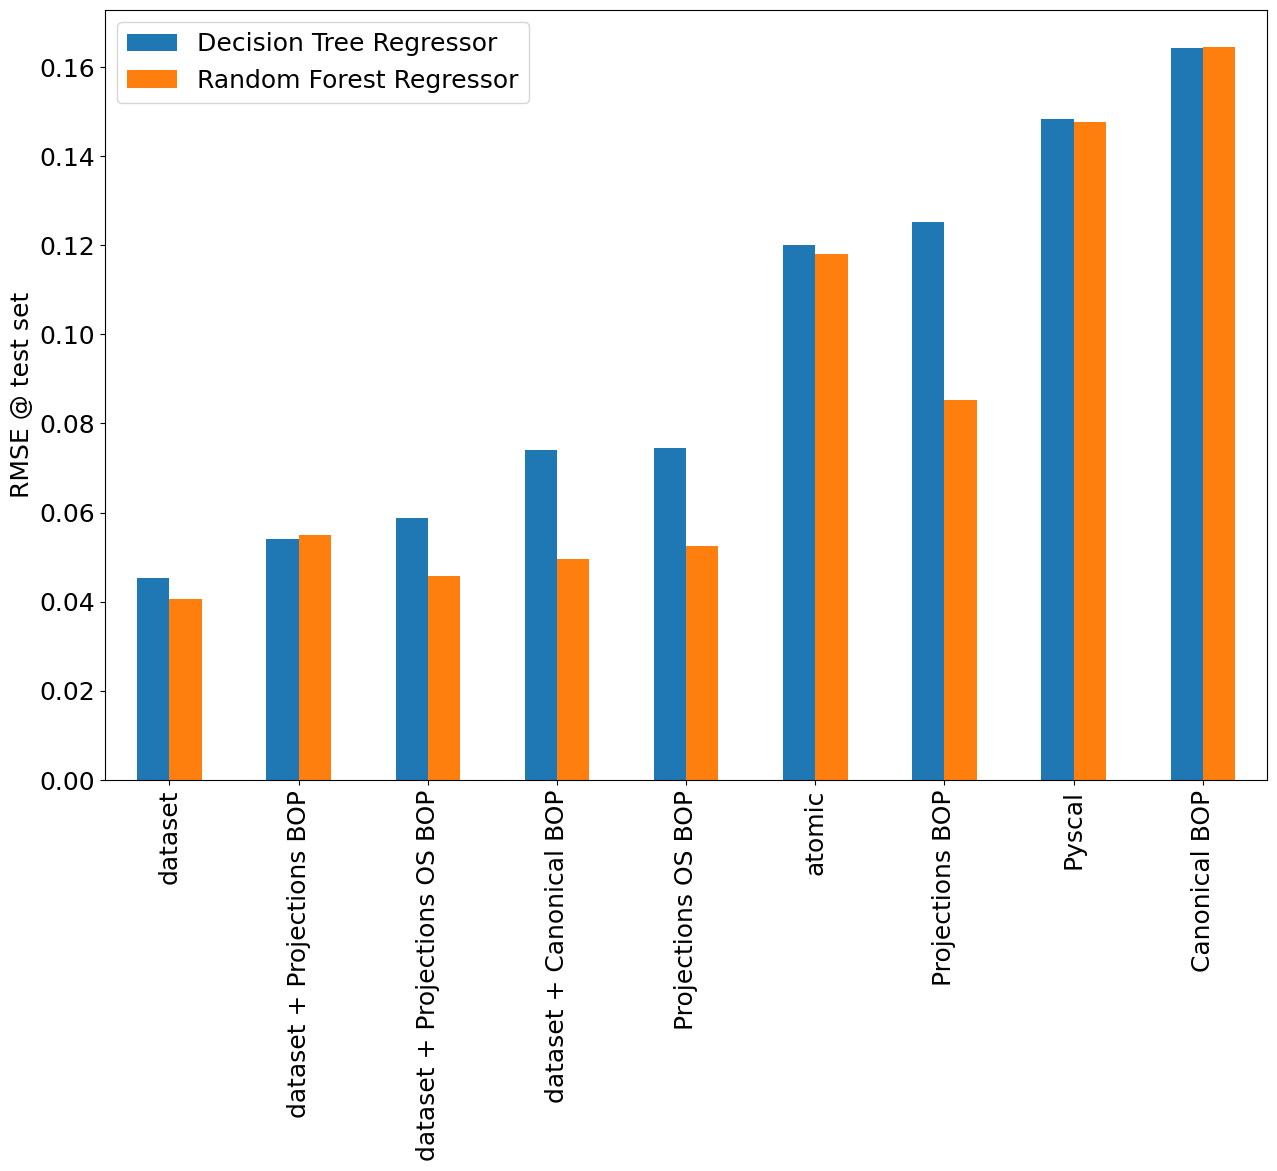

In [20]:
ax = sorted.plot(kind='bar')
ax.set_ylabel('RMSE @ test set')

# Test for overfitting 

In [21]:
thisexample = ('Decision Tree Regressor', 'Projections BOP')

In [22]:
importances = gridsearch[thisexample].best_estimator_['regressor'].feature_importances_

In [23]:
names = gridsearch[thisexample].best_estimator_['regressor'].feature_names_in_

In [24]:
sorter = np.argsort(importances)

In [25]:
best_score = {'test':{}, 'train':{}}

In [26]:
%store -r best_score

In [27]:
progress = tqdm(range(Features[thisexample[1]].shape[1]))
for nbest in progress:
    if nbest in best_score['test'].keys():
        continue
    X = Features[thisexample[1]][names[sorter][-nbest:]]
    Y = BS['EF']
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)
    gridsearch_onbest = GridSearchCV(models[thisexample[0]], param_grid=params[thisexample[0]], scoring='neg_root_mean_squared_error')
    gridsearch_onbest.fit(X, Y)
    Ypredict_train = gridsearch_onbest.predict(xtrain)
    Ypredict_test = gridsearch_onbest.predict(xtest)
    best_score['test'].update({nbest: mean_squared_error(ytest,Ypredict_test )})
    best_score['train'].update({nbest: mean_squared_error(ytrain,Ypredict_train )})
    line1.set_ydata(list(best_score['test'].values()))
    line1.set_xdata(list(best_score['test'].keys()))
    
    

  0%|          | 0/476 [00:00<?, ?it/s]

In [ ]:
plt.plot(np.sqrt(best_score['test'].values()),'--o')
plt.plot(np.sqrt(best_score['train'].values()),'--o')

In [83]:
%store best_score

Stored 'best_score' (dict)
ERROR! Session/line number was not unique in database. History logging moved to new session 4592


In [67]:
scores_df = pd.DataFrame(best_score)

In [75]:
Features[thisexample[1]].columns

Index(['U_bind', 'U_bond_atom', 'moments_1_0', 'moments_1_CN12',
       'moments_1_CN13', 'moments_1_CN14', 'moments_1_CN15', 'moments_1_CN16',
       'moments_2_0', 'moments_2_CN12',
       ...
       'Ainf_1_CN13', 'Ainf_1_CN14', 'Ainf_1_CN15', 'Ainf_1_CN16', 'Binf_1_0',
       'Binf_1_CN12', 'Binf_1_CN13', 'Binf_1_CN14', 'Binf_1_CN15',
       'Binf_1_CN16'],
      dtype='object', length=476)

In [80]:
indexesgood = list(scores_df[scores_df['test'].diff()<0].index)

In [81]:
suposedlygood = Features[thisexample[1]].columns[indexesgood]

In [82]:
suposedlygood

Index(['moments_1_0', 'moments_1_CN12', 'moments_1_CN13', 'moments_1_CN14',
       'moments_1_CN15', 'moments_2_0', 'moments_2_CN13', 'moments_2_CN14',
       'moments_2_CN15', 'moments_2_CN16', 'moments_3_0', 'moments_3_CN12',
       'moments_3_CN13', 'moments_3_CN14', 'moments_4_CN13', 'moments_4_CN14',
       'moments_4_CN16', 'moments_5_CN12', 'moments_5_CN13', 'moments_5_CN15',
       'moments_6_CN12', 'moments_6_CN14', 'moments_6_CN16', 'moments_7_CN13',
       'moments_7_CN15', 'moments_8_0', 'moments_8_CN12', 'moments_8_CN13',
       'moments_9_0', 'moments_9_CN13', 'moments_9_CN14', 'moments_10_CN12',
       'moments_11_CN12', 'moments_11_CN13', 'moments_13_CN13',
       'moments_13_CN15'],
      dtype='object')

In [151]:
thisexample

('Decision Tree Regressor', 'Projections BOP')

In [25]:
gridsearch[thisexample].feature_names_in_

array(['moments_1_0', 'moments_2_0', 'moments_3_0', 'moments_4_0',
       'moments_5_0', 'moments_6_0', 'moments_7_0', 'moments_8_0',
       'moments_9_0', 'moments_10_0', 'moments_11_0', 'moments_12_0',
       'moments_13_0', 'moments_14_0', 'moments_15_0',
       'normed_moments_1_0', 'normed_moments_2_0', 'normed_moments_3_0',
       'normed_moments_4_0', 'normed_moments_5_0', 'normed_moments_6_0',
       'normed_moments_7_0', 'normed_moments_8_0', 'normed_moments_9_0',
       'normed_moments_10_0', 'normed_moments_11_0',
       'normed_moments_12_0', 'normed_moments_13_0',
       'normed_moments_14_0', 'normed_moments_15_0', 'an_1_0', 'an_2_0',
       'an_3_0', 'an_4_0', 'an_5_0', 'an_6_0', 'an_7_0', 'an_8_0',
       'an_9_0', 'an_10_0', 'an_11_0', 'an_12_0', 'an_13_0', 'an_14_0',
       'an_15_0', 'an_16_0', 'bn_1_0', 'bn_2_0', 'bn_3_0', 'bn_4_0',
       'bn_5_0', 'bn_6_0', 'bn_7_0', 'bn_8_0', 'bn_9_0', 'bn_10_0',
       'bn_11_0', 'bn_12_0', 'bn_13_0', 'bn_14_0', 'bn_15_0', 'bn_1

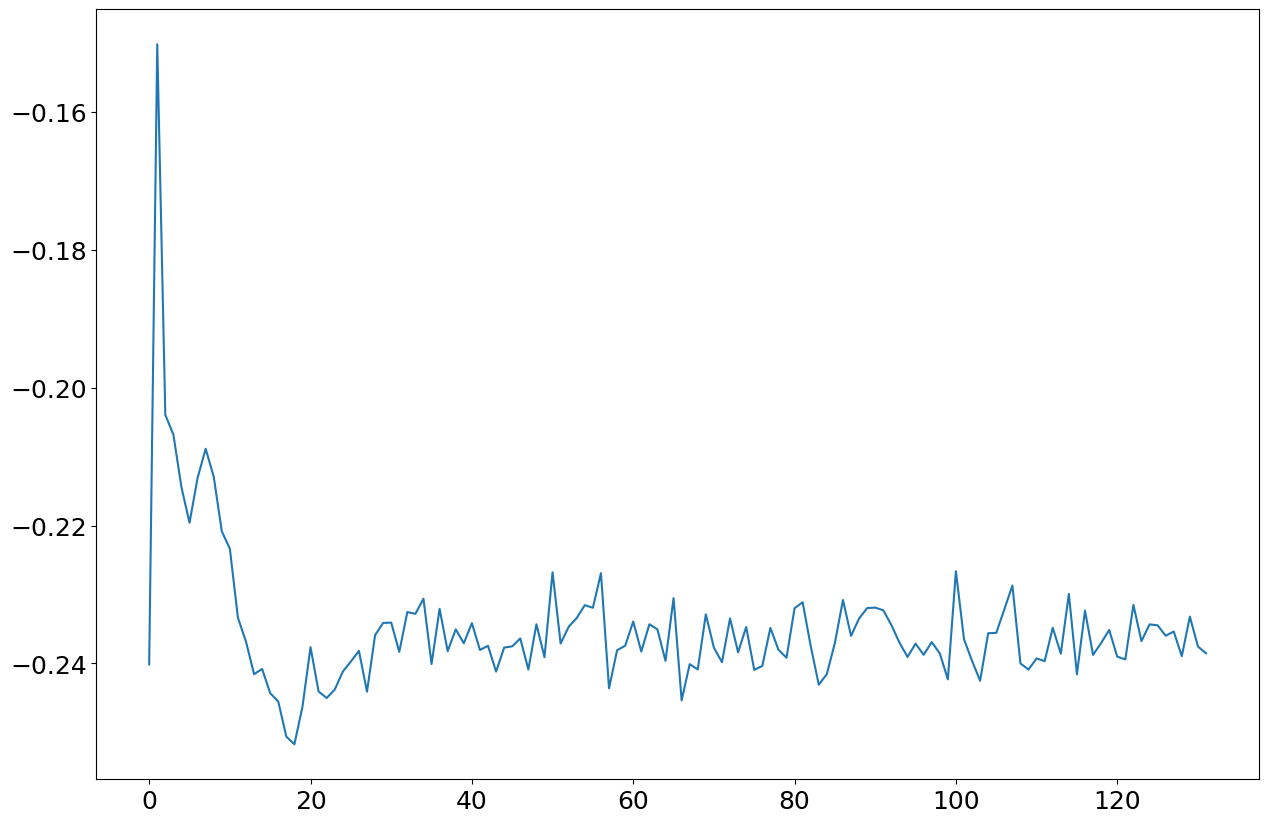

In [142]:
plt.plot(best_score)

## All the features (including CPAV)

In [39]:
combis = product(models.items(),  Features.items())
Y = BS[target]#[X.index]
# RMSE={name:{} for name in Features.keys()}
RMSEwCPAV = {}
for (modelname, model), (name, thisfeature) in tqdm(combis, total=len(models)*len(Features)):
    intersectindex  = Y.index.intersection(thisfeature.index)
    x = thisfeature
    if 'dataset' not in thisfeature:
        X = pd.concat([x, Features['dataset'].filter(regex='Structure|Mag')], axis=1).loc[intersectindex]
    thisY = Y.loc[intersectindex]
    xtrain, xtest, ytrain, ytest = train_test_split(X, thisY, test_size=0.2, shuffle=True)
    model.fit(xtrain, ytrain)# , **fit_params[modelname])
    model.set_params(**params[modelname])
    Ypredict = model.predict(xtrain)
    Ypredicttest = model.predict(xtest)
    RMSEwCPAV[(modelname, name)] = {'train': mean_squared_error(ytrain, Ypredict, squared=False), 'test' : mean_squared_error(ytest, Ypredicttest, squared=False)}

  0%|          | 0/18 [00:00<?, ?it/s]

In [40]:
combis = product(models.items(),  Features.items())
Y = BS[target]#[X.index]
for (modelname, model), (name, thisfeature) in tqdm(combis, total = len(models)*len(Features)):
    if 'BOP' not in name:
        continue
    X = pd.concat([thisfeature, Features['dataset']], axis = 1) #.filter(regex='_0$')
    X.dropna(inplace=True)
    intersectindex  = Y.index.intersection(X.index)
    thisY = Y.loc[intersectindex]
    xtrain, xtest, ytrain, ytest = train_test_split(X.loc[intersectindex], thisY.loc[intersectindex], test_size=0.2, shuffle=True)
    model.fit(xtrain, ytrain)# , **fit_params[modelname])
    model.set_params(**params[modelname])
    Ypredict = model.predict(xtrain)
    Ypredicttest = model.predict(xtest)
    RMSEwCPAV[(modelname, 'dataset +'+name)] = {'train': mean_squared_error(ytrain, Ypredict, squared=False), 'test' : mean_squared_error(ytest, Ypredicttest, squared=False)}

  0%|          | 0/18 [00:00<?, ?it/s]

In [41]:
dfRMSEwCPAV = pd.DataFrame.from_dict(RMSE, orient='index')
dfRMSEwCPAV.sort_values(by='test', inplace=True)

(0.0, 0.2)

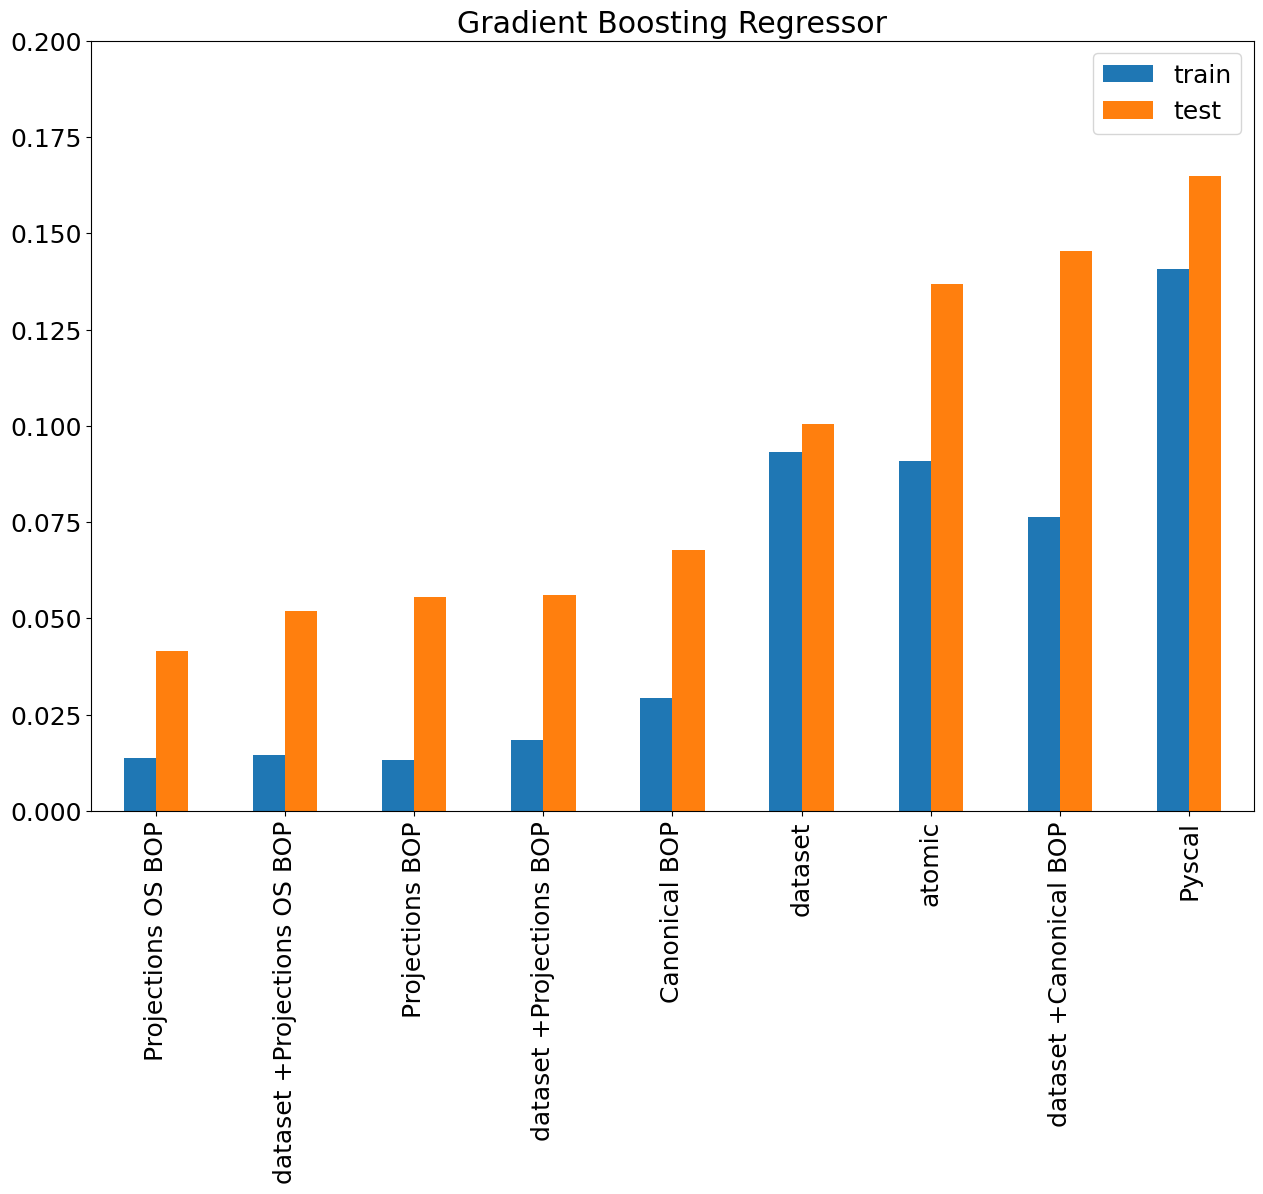

In [43]:
ax = dfRMSEwCPAV.loc['Gradient Boosting Regressor'].plot(kind = 'bar', )
ax.set_title('Gradient Boosting Regressor')
ax.set_ylim([0,0.2])

In [45]:
sortedwcpav = dfRMSEwCPAV['test'].unstack(level=0).sort_values(by='Gradient Boosting Regressor')

Text(0, 0.5, 'RMSE @ test set')

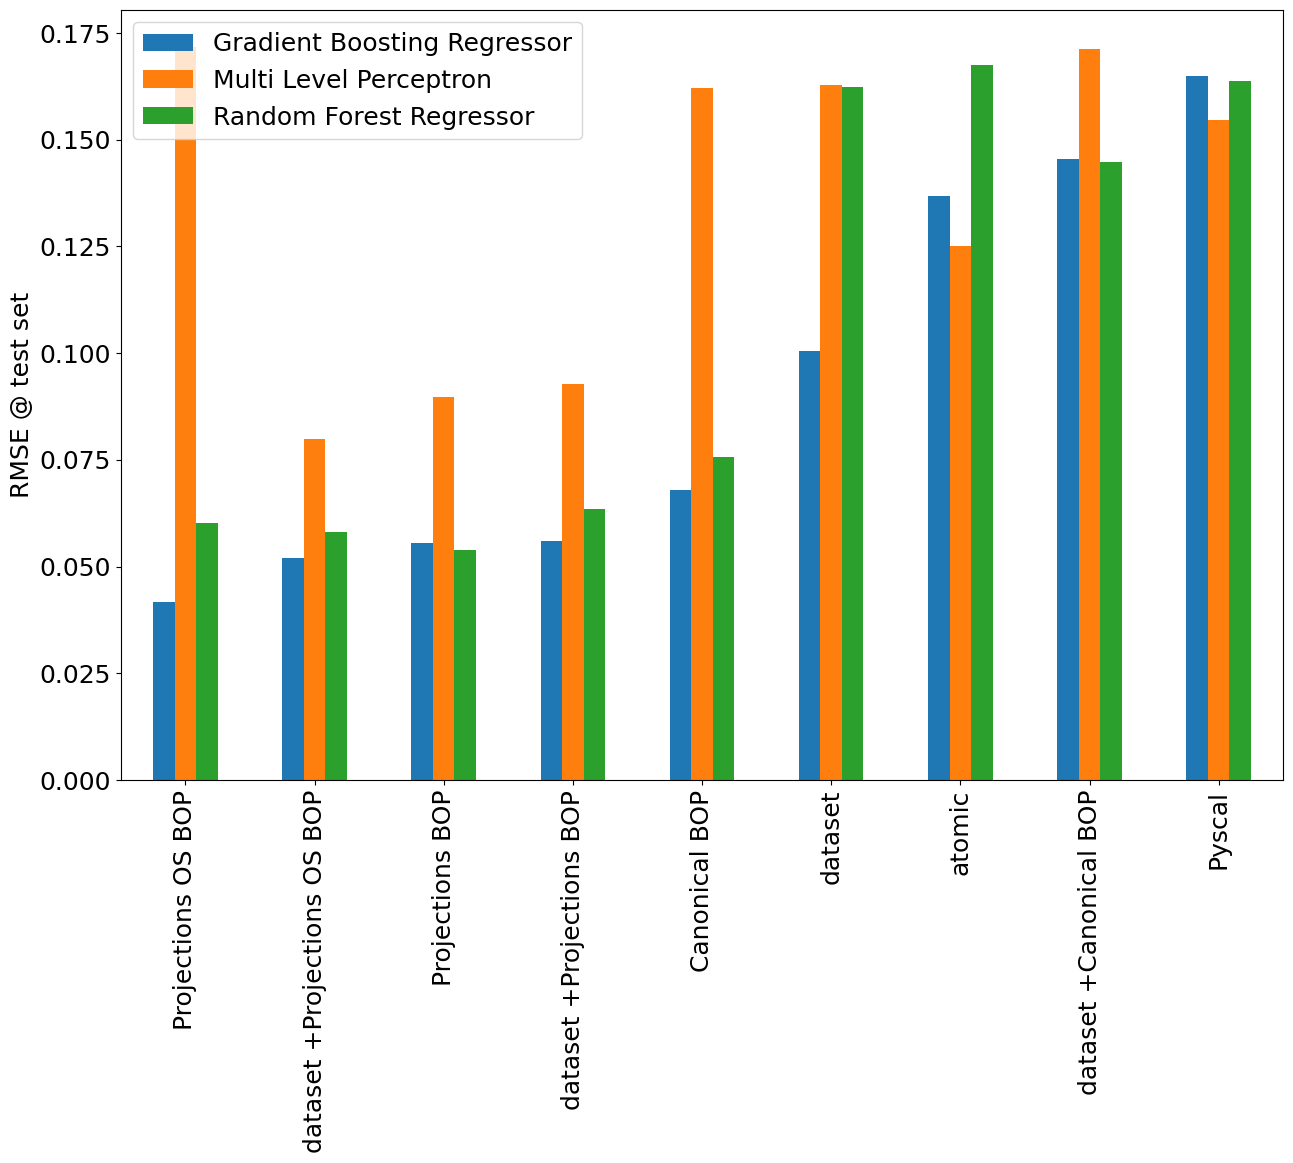

In [46]:
ax = sortedwcpav.plot(kind='bar')
ax.set_ylabel('RMSE @ test set')

In [47]:
trainedmodels

{}

In [49]:
sorter = np.argsort(models['Gradient Boosting Regressor']['regressor'].feature_importances_)

In [51]:
models['Gradient Boosting Regressor']['regressor'].feature_names_in_[sorter]

array(['an_10_CN15', 'an_16_CN13', 'an_16_CN12', 'an_16_0', 'an_15_CN16',
       'an_15_CN15', 'an_15_CN14', 'an_15_CN13', 'an_15_CN12', 'an_15_0',
       'an_14_CN16', 'an_14_CN15', 'an_14_CN14', 'an_14_CN13',
       'an_14_CN12', 'an_14_0', 'an_13_CN16', 'an_13_CN15', 'an_13_CN14',
       'an_13_CN13', 'an_16_CN14', 'an_16_CN15', 'an_16_CN16',
       'bn_1_CN13', 'bn_8_0', 'bn_7_CN15', 'bn_7_CN14', 'bn_7_CN13',
       'bn_6_CN15', 'bn_6_CN13', 'bn_5_CN16', 'bn_5_CN14', 'bn_5_CN13',
       'an_13_CN12', 'bn_5_CN12', 'bn_4_CN14', 'bn_4_CN13', 'bn_3_CN16',
       'bn_3_CN13', 'bn_3_0', 'bn_2_CN15', 'bn_2_CN13', 'bn_2_CN12',
       'bn_1_CN16', 'bn_4_CN15', 'an_13_0', 'an_12_CN16', 'an_12_CN15',
       'an_8_CN14', 'an_8_CN13', 'an_8_CN12', 'an_8_0', 'an_7_CN16',
       'an_7_CN15', 'an_7_CN13', 'an_6_CN14', 'an_6_CN13', 'an_8_CN15',
       'an_5_CN15', 'an_5_CN13', 'an_4_CN15', 'an_4_CN14', 'an_4_CN13',
       'an_4_CN12', 'an_3_CN16', 'an_3_CN14', 'an_3_CN13', 'an_3_CN12',
       'an_5

In [53]:
'U_bind' in models['Gradient Boosting Regressor']['regressor'].feature_names_in_

True

# Accumulating knowledge

In [54]:
Y = BS[target]

In [55]:
thisfeatures  = Features['Projections BOP'].filter(regex='normed_moments.*_0$')

In [56]:
thismodelname = 'Random Forest Regressor'

In [57]:
RMSEincremental = {}
for i, column in tqdm(enumerate(thisfeatures.columns), total = thisfeatures.shape[1]):
    X = pd.concat([Features['dataset']['Mag'],thisfeatures.iloc[:,:i+1]], axis=1)
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, shuffle=True)
    models[thismodelname].fit(xtrain, ytrain)
    Ypredict = models[thismodelname].predict(xtrain)
    Ypredicttest = models[thismodelname].predict(xtest)
    RMSEincremental[(thismodelname, column)] = {
        'train' : mean_squared_error(ytrain, Ypredict, squared = False),
        'test' : mean_squared_error(ytest, Ypredicttest, squared=False)
    }
    

  0%|          | 0/15 [00:00<?, ?it/s]

In [58]:
pd.DataFrame.from_dict(RMSEincremental, orient='index')

train      test
Random Forest Regressor normed_moments_1_0   0.061695  0.145804
                        normed_moments_2_0   0.045114  0.105473
                        normed_moments_3_0   0.041706  0.111503
                        normed_moments_4_0   0.042757  0.107332
                        normed_moments_5_0   0.041815  0.104937
                        normed_moments_6_0   0.040740  0.106659
                        normed_moments_7_0   0.042084  0.091586
                        normed_moments_8_0   0.038932  0.124268
                        normed_moments_9_0   0.040738  0.100193
                        normed_moments_10_0  0.040245  0.135347
                        normed_moments_11_0  0.041885  0.079497
                        normed_moments_12_0  0.040759  0.105403
                        normed_moments_13_0  0.038091  0.092087
                        normed_moments_14_0  0.038362  0.103286
                        normed_moments_15_0  0.038807  0.092342

In [59]:
thismodel = RandomForestRegressor()

In [60]:
thismodel.fit(Features['dataset'], Y)

RandomForestRegressor()

In [61]:
Ypredict = thismodel.predict(Features['dataset'])

In [62]:
mean_squared_error(Y, Ypredict, squared=False)

0.0866553152689

# Feature Selection 

In [64]:

models

{'Gradient Boosting Regressor': Pipeline(steps=[('regressor', GradientBoostingRegressor())]),
 'Random Forest Regressor': Pipeline(steps=[('regressor', RandomForestRegressor(max_depth=10))]),
 'Multi Level Perceptron': Pipeline(steps=[('scaler', StandardScaler()), ('regressor', MLPRegressor())])}

In [63]:
sortedfeatures={}
for name, modelname in product(Features.keys(), models.keys()):#('atomic', 'Gradient Boosting Regressor')
    importances = models[(name, modelname)].feature_importances_
    sorter = np.flip(importances.argsort())
    sortedfeatures[(name, modelname)] = {'features': trainedmodels[(name, modelname)].feature_names_in_[sorter], 'importances' :  importances[sorter]}
#    ax = sns.barplot(y=  sortedfeatures[(name, modelname)][:10], x=importances[sorter][:10])
#    ax.set_xlabel('importance')

KeyError: ('atomic', 'Gradient Boosting Regressor')

In [ ]:
dfImportances = pd.DataFrame.from_dict(sortedfeatures, orient='index')

In [107]:
dfImportances

features  \
atomic             Gradient Boosting Regressor  [MagpieData mean NfValence, MagpieData mean Ro...   
                   Random Forest Regressor      [MagpieData mean NfValence, MagpieData mean Ro...   
dataset            Gradient Boosting Regressor  [Z_CN12, Z_CN16, W_sv, Co_pv, Z_CN14, Cr_pv, Z...   
                   Random Forest Regressor      [Z_CN12, Z_CN16, Co_pv, W_sv, Cr_pv, Z_CN15, M...   
Canonical BOP      Gradient Boosting Regressor  [moments_5_0, bn_8_0, moments_9_0, bn_4_0, bn_...   
                   Random Forest Regressor      [moments_7_0, moments_5_0, moments_9_0, bn_2_0...   
Projections BOP    Gradient Boosting Regressor  [sigma_10_CN12, bn_5_CN16, sigma_5_CN16, sigma...   
                   Random Forest Regressor      [sigma_3_CN16, sigma_10_CN12, bn_5_CN16, bn_6_...   
Projections OS BOP Gradient Boosting Regressor  [bn_6_CN12, bn_3_CN12, normed_moments_5_CN16, ...   
                   Random Forest Regressor      [bn_3_CN12, bn_6_CN12, bn_1_CN12, sigma_8_CN16...   

                                                                                      importances  
atomic             Gradient Boosting Regressor  [0.15473719555150303, 0.13842148075128877, 0.0...  
                   Random Forest Regressor      [0.14580496183937028, 0.12533700563947206, 0.0...  
dataset            Gradient Boosting Regressor  [0.6645995344183917, 0.07986304480290186, 0.07...  
                   Random Forest Regressor      [0.6037874720919301, 0.09307276781121251, 0.08...  
Canonical BOP      Gradient Boosting Regressor  [0.15917176147623027, 0.14425433515454442, 0.1...  
                   Random Forest Regressor      [0.114906802217047, 0.11312009906487926, 0.090...  
Projections BOP    Gradient Boosting Regressor  [0.10201537091888886, 0.08254993206666165, 0.0...  
                   Random Forest Regressor      [0.1308355686672533, 0.10222343142821493, 0.05...  
Projections OS BOP Gradient Boosting Regressor  [0.4641895730084643, 0.0740207124499817, 0.021...  
                   Random Forest Regressor      [0.26350942368156977, 0.20770515171153417, 0.0...

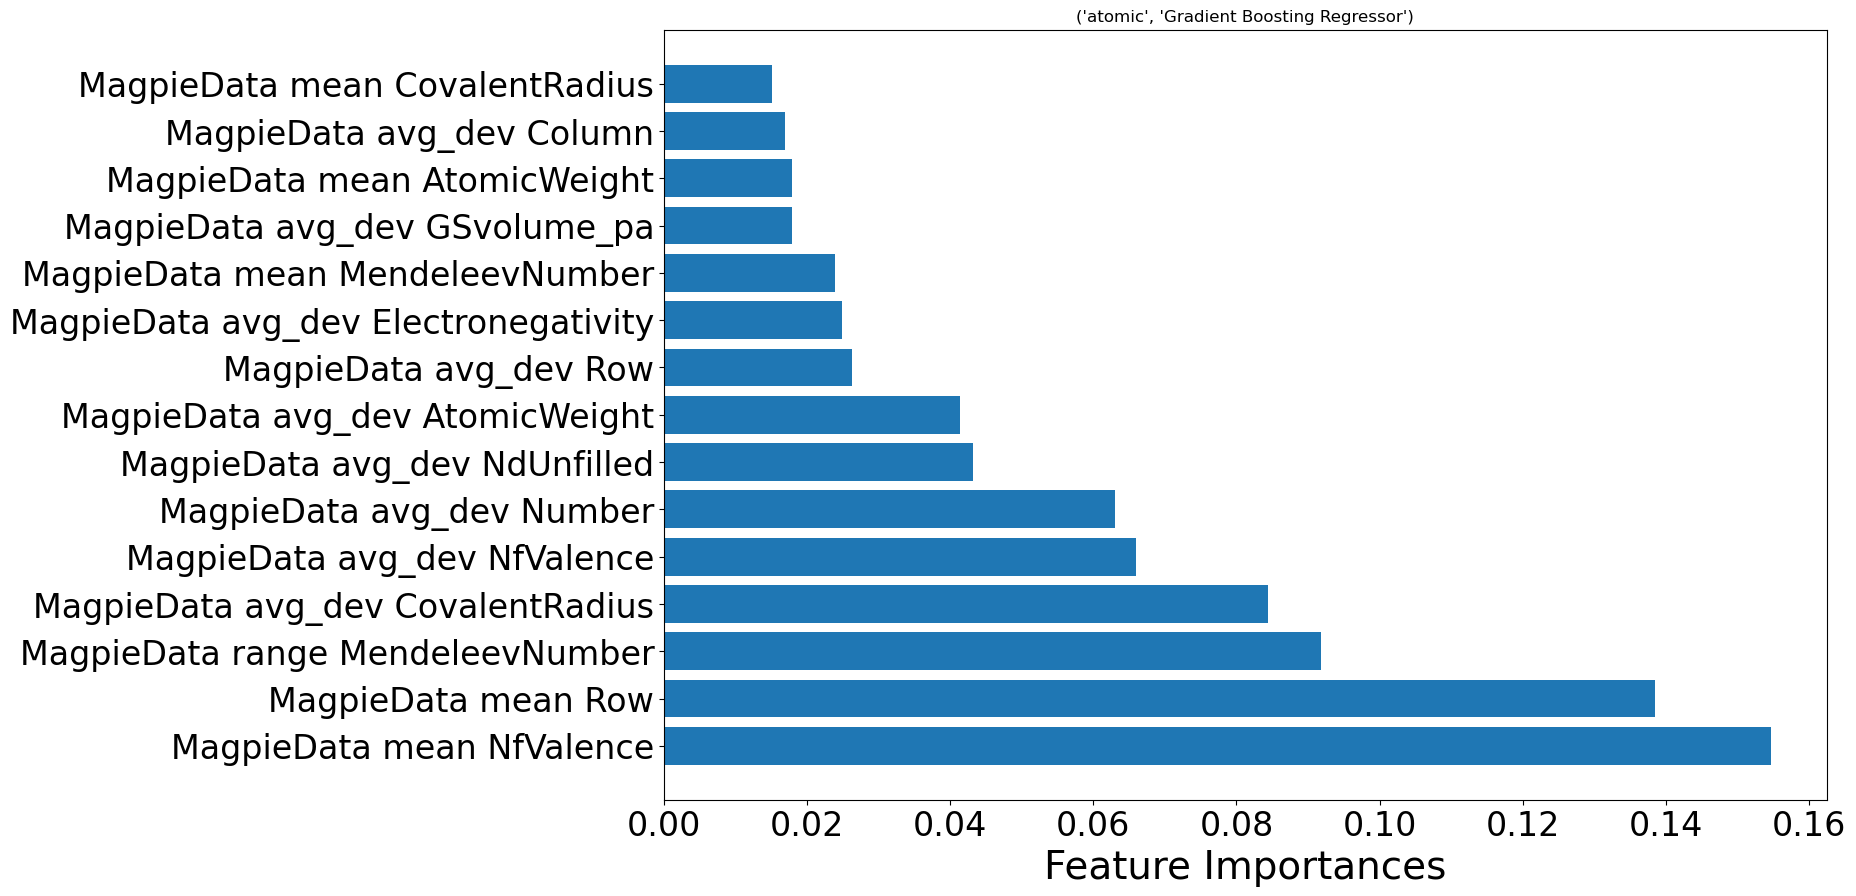

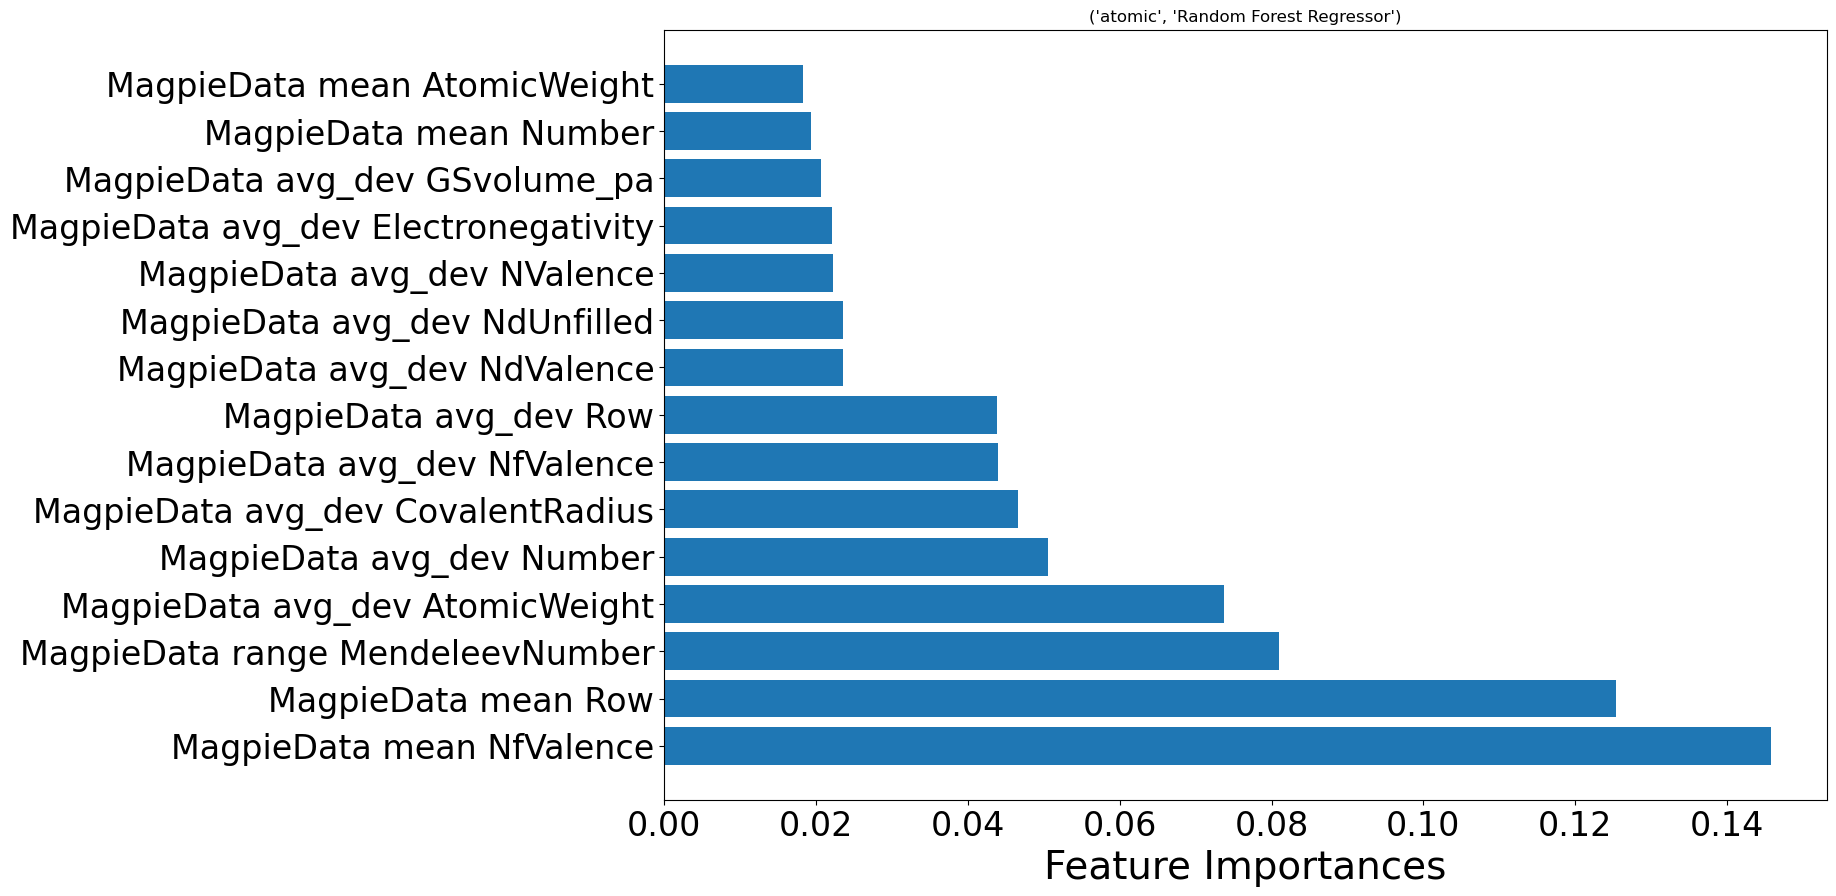

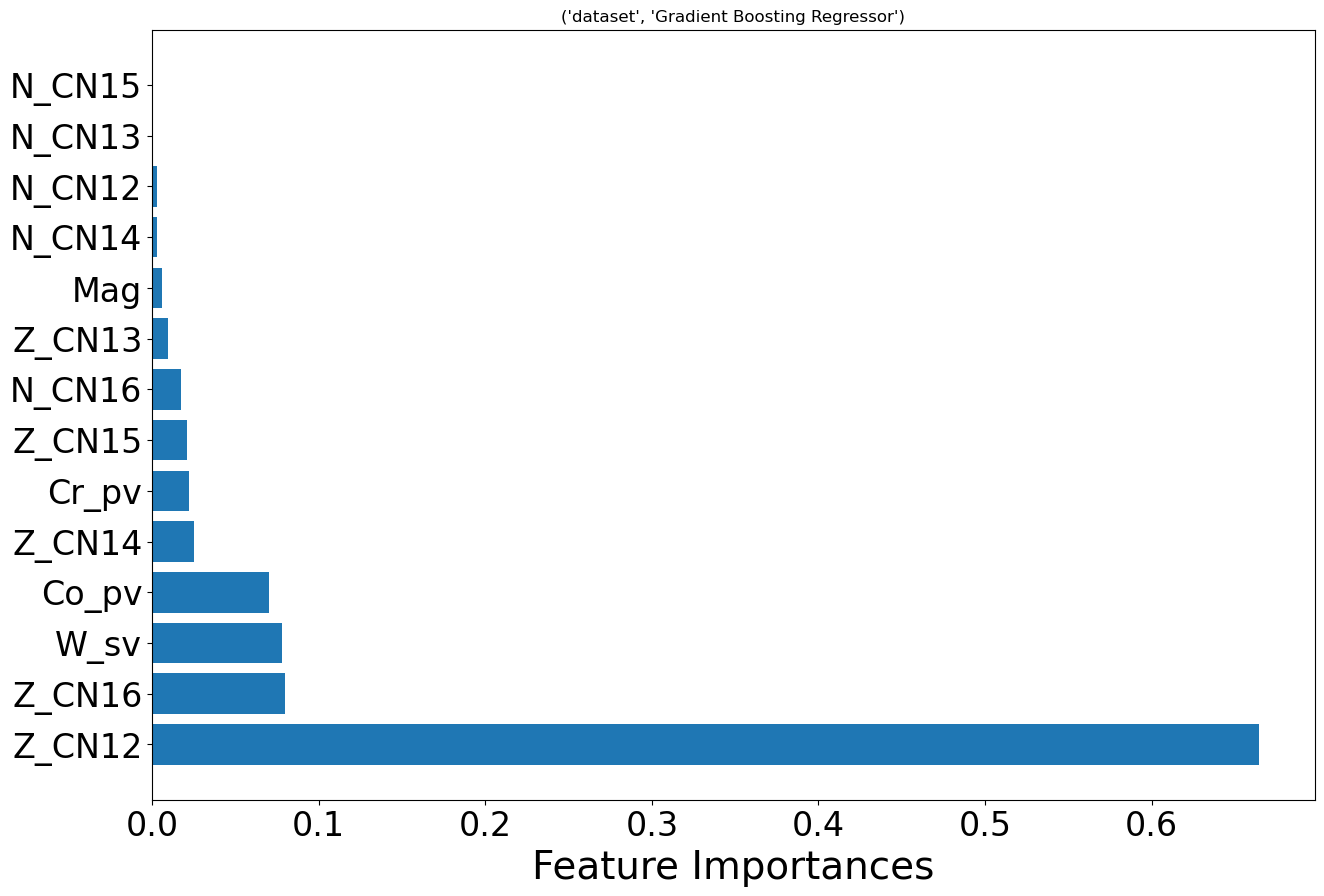

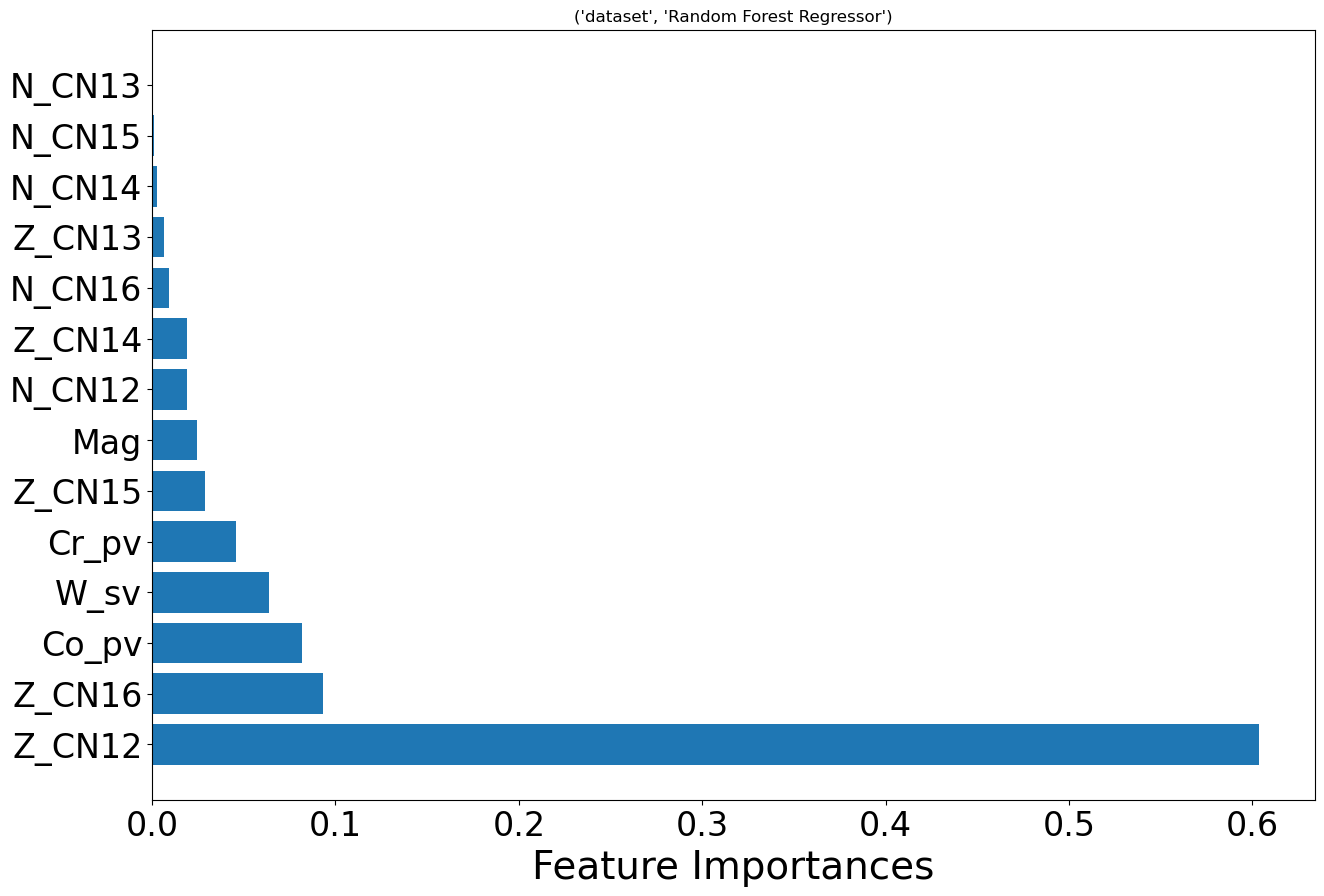

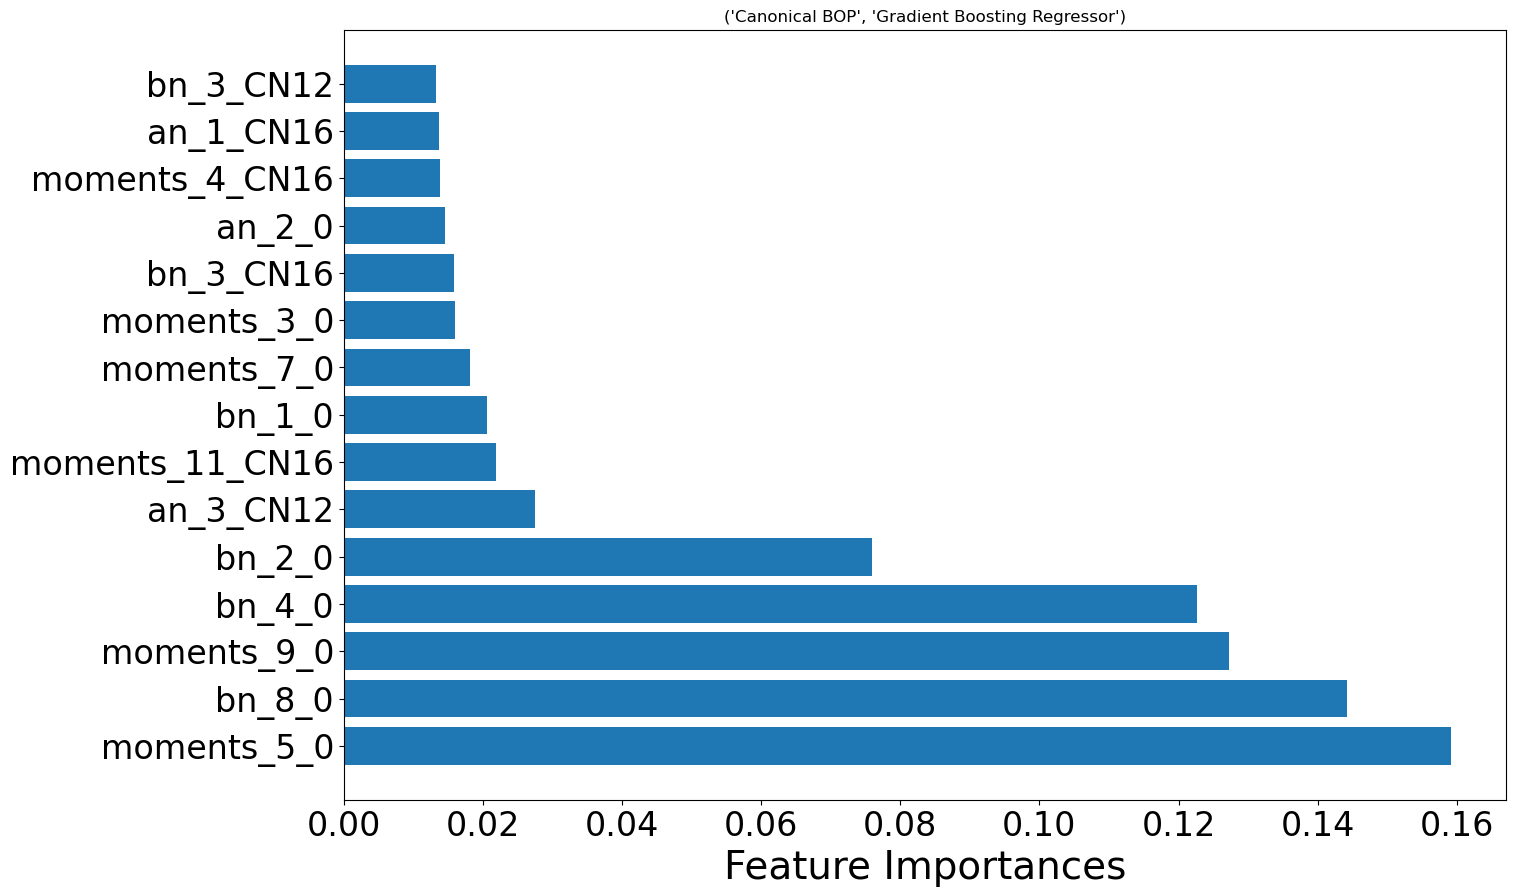

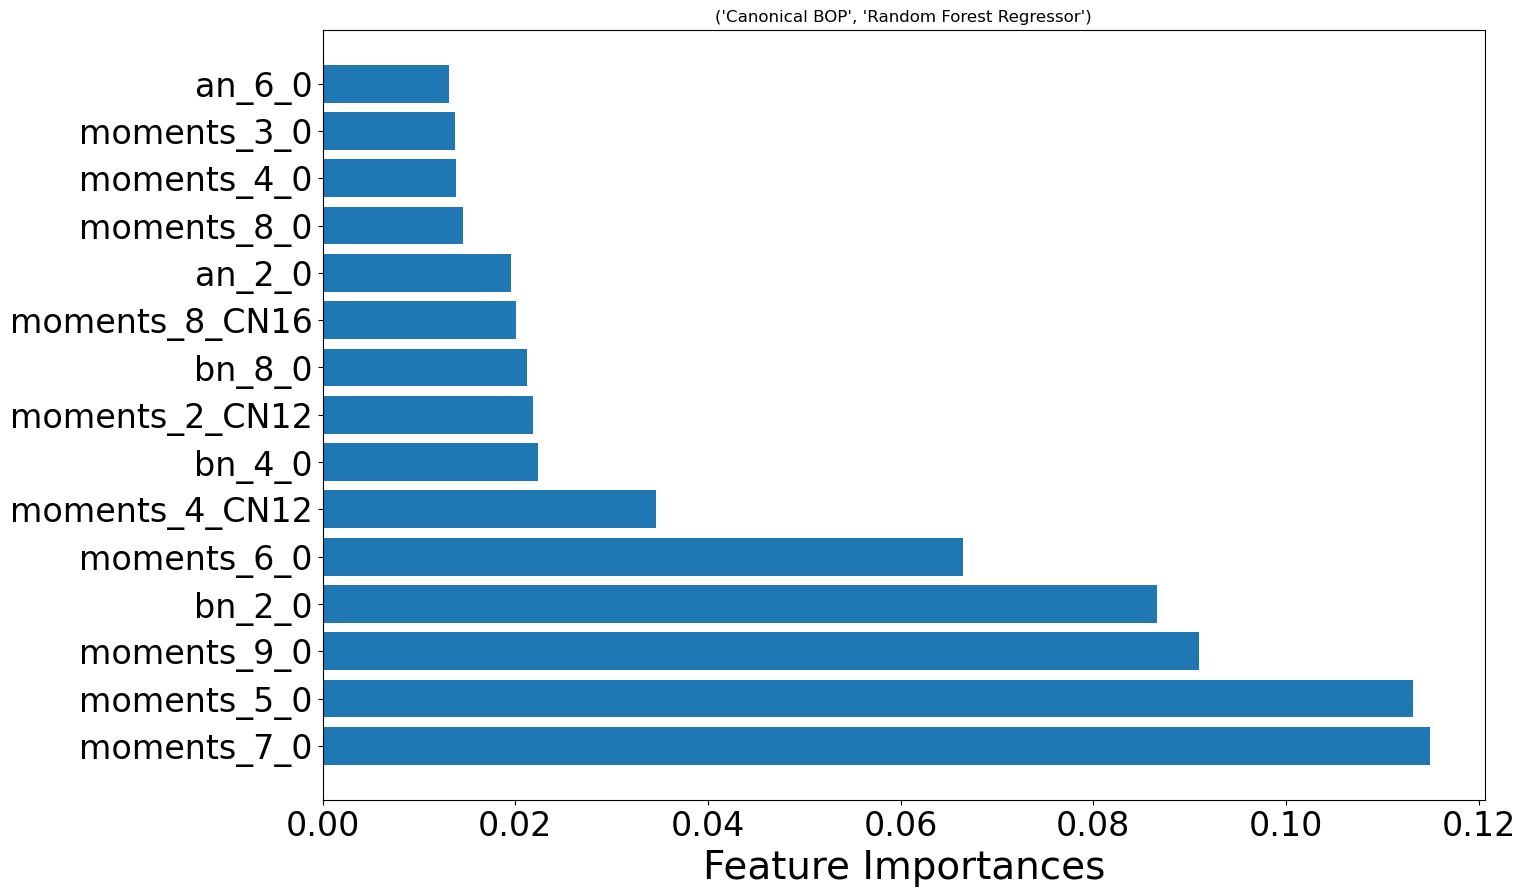

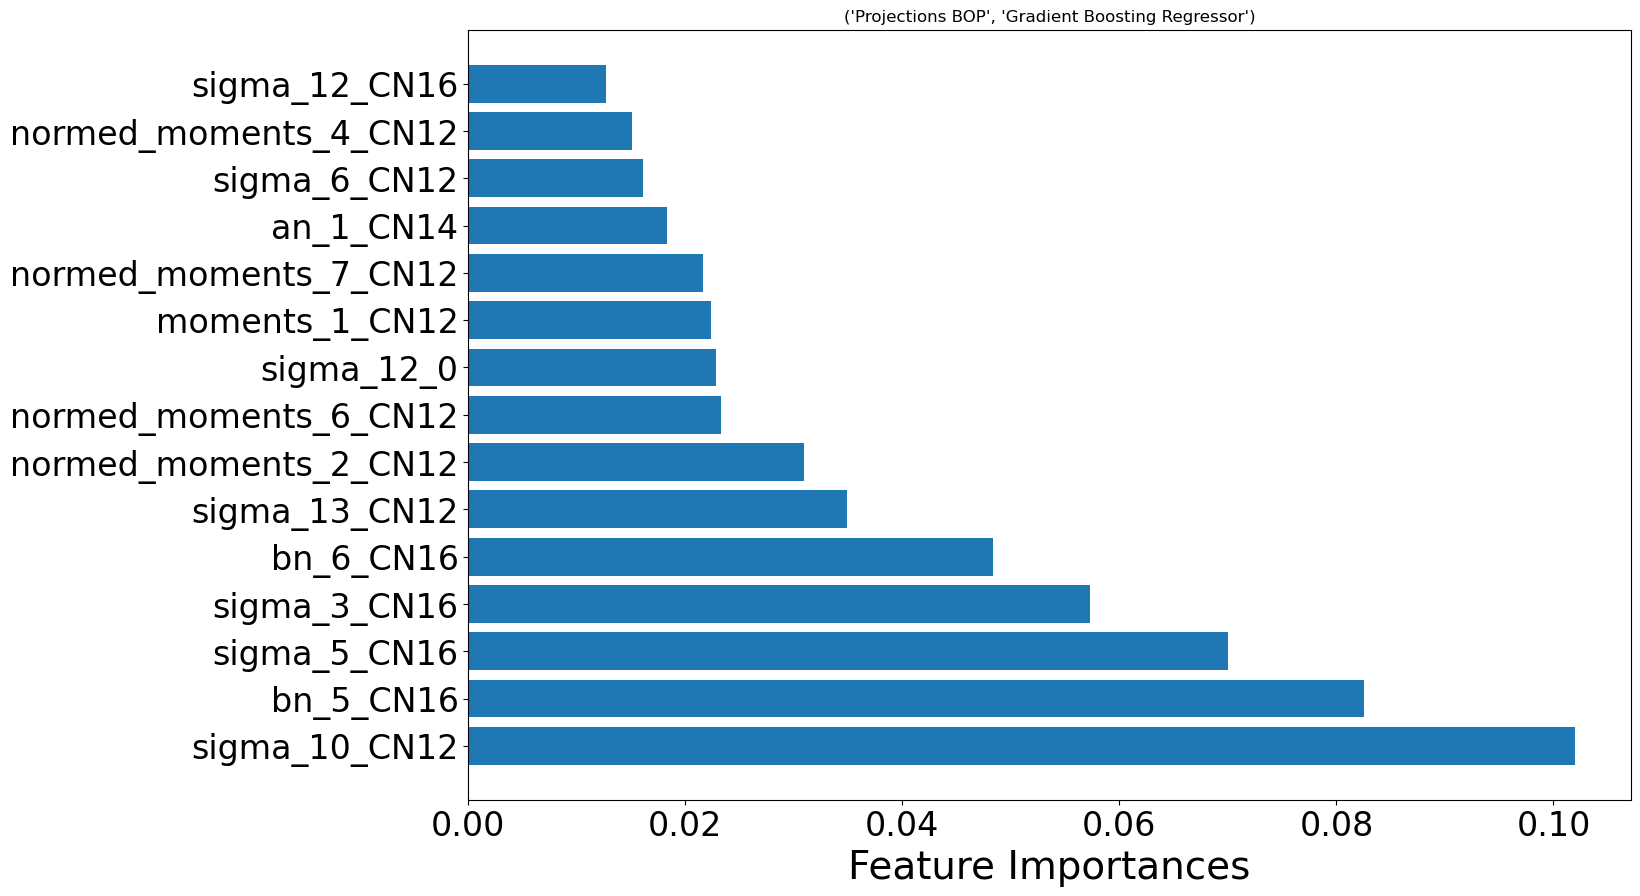

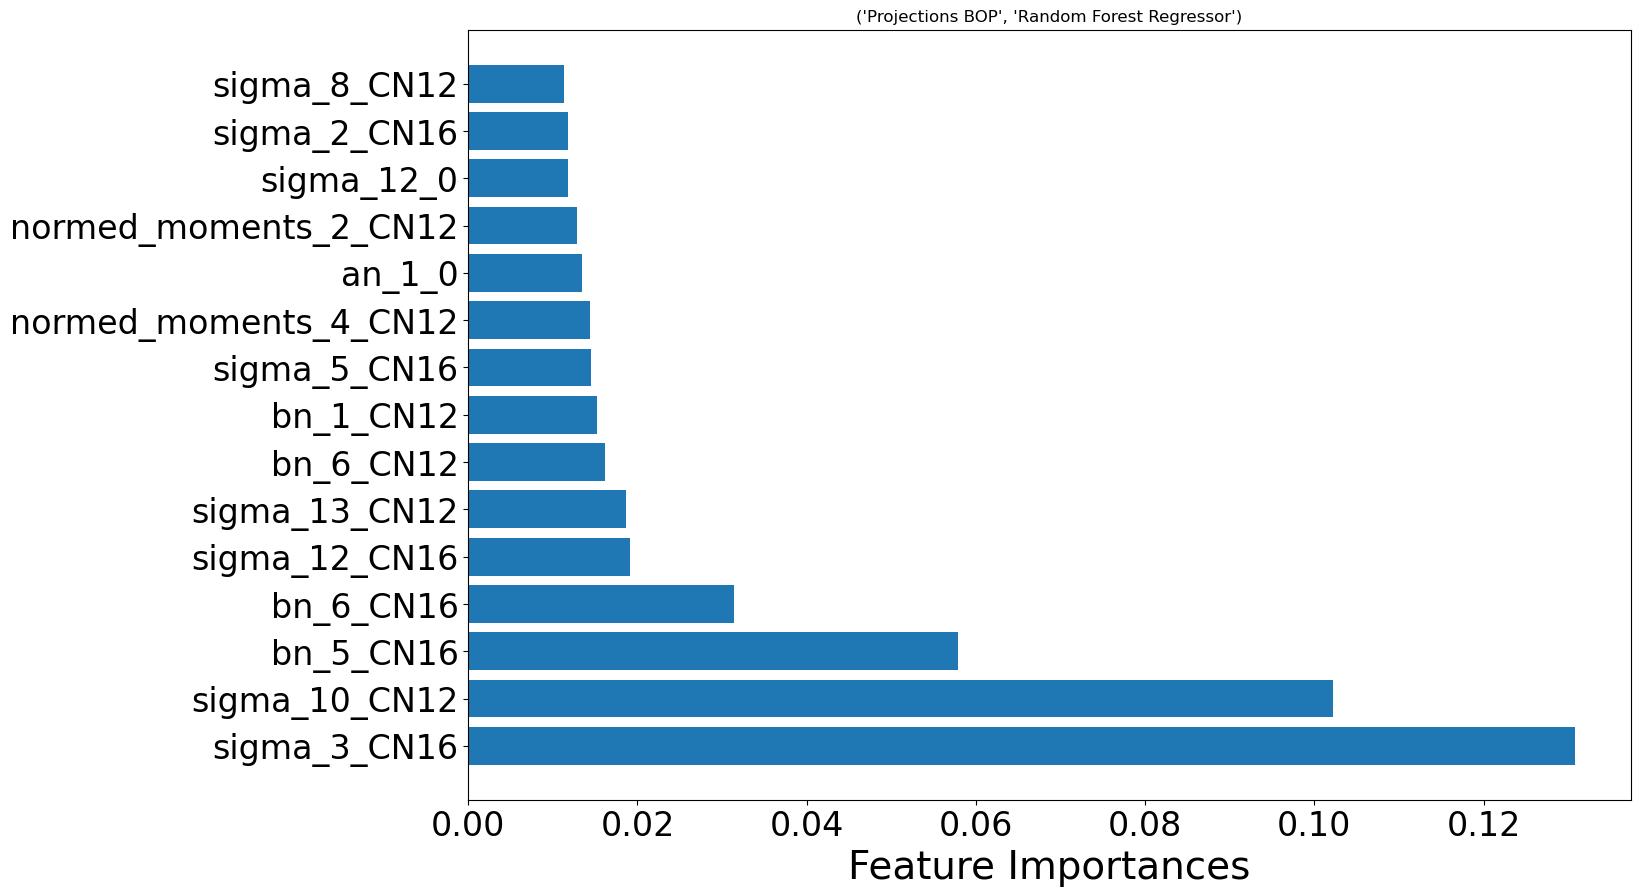

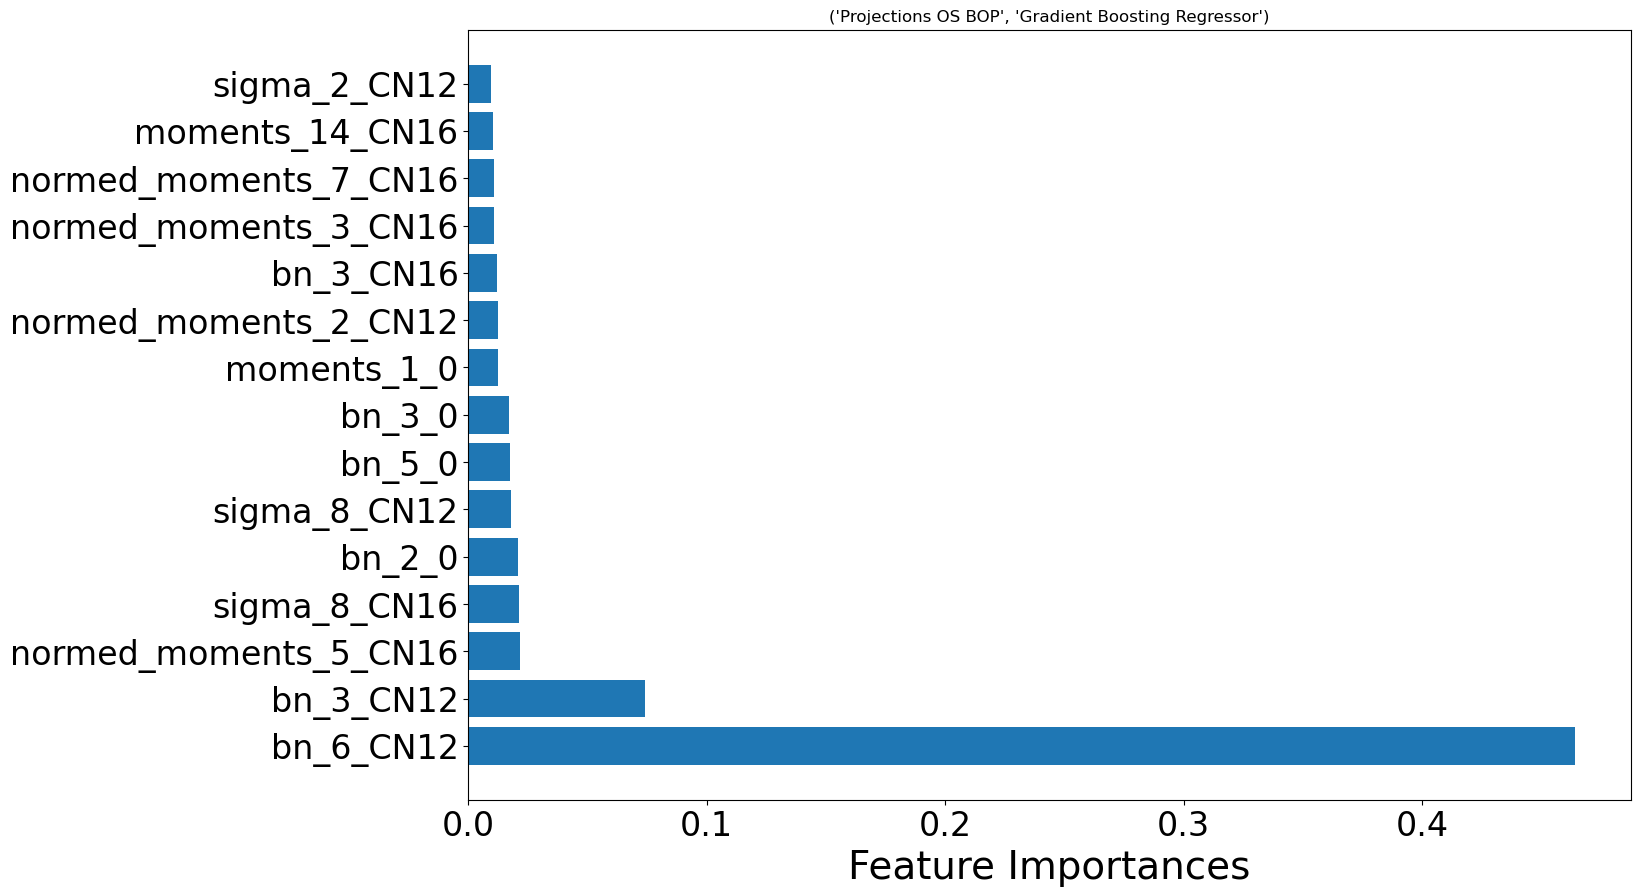

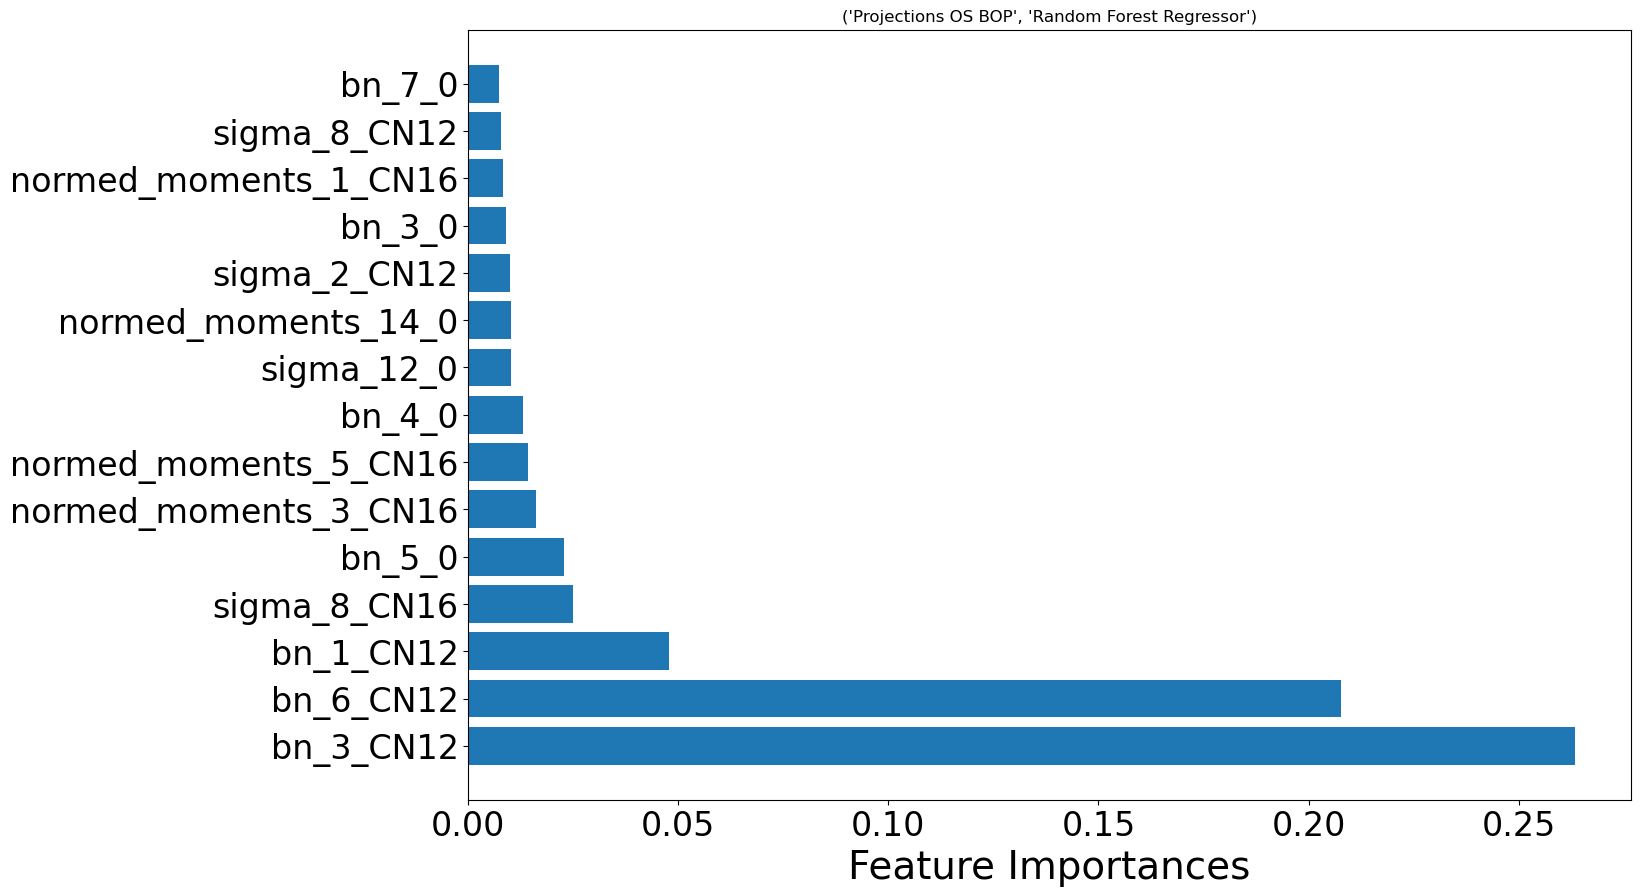

In [130]:
for index, (featlist, importancelist) in dfImportances.iterrows():
    fig, ax = plt.subplots()
    ax.barh(featlist[:nfeatures], importancelist[:nfeatures])
    ax.set_title(index)
    ax.set_xlabel('Feature Importances')

# Feature importances

In [ ]:
from sk

# Predictions for separate features 

- separate train / test sets 

# Helper Functions 

In [ ]:
from Tools import CaseNamer, Plotting

In [ ]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [ ]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [ ]:
BOPCOEF_FILE = f'CRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}_{MOMENTS}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

## clean features: reduntandly convert all features to float and mean across sites

In [ ]:
BopfoxFeatures.dropna(how='any',inplace=True)
M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
Mag = Features.MagFeature[BopfoxFeatures.index]
BOP_atom_average = pd.concat([BopfoxFeatures['NSC_U_bind'],M, S, AN, BN, Ainf, Binf, Mag], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)

## define the column names by type of feature

In [ ]:
allcolumns = BOP.columns

In [ ]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [ ]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [ ]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [ ]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [ ]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [ ]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [ ]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [ ]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [ ]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [ ]:
DATA.shape

## B0

In [ ]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## V0

In [ ]:
DATA = DATA[DATA['V0']<50]

In [ ]:
DATA.shape

## Drop Nans !

In [ ]:
DATA.dropna(how='any', axis=0,inplace=True)

# Classification and weighting

In [ ]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [ ]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [ ]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [ ]:
from sklearn.feature_selection import  (RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [ ]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [ ]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

In [ ]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [ ]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [ ]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [ ]:
simple_model.fit(X_train,Y_train)

In [ ]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [ ]:
mses

In [ ]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [ ]:
simple_model_noscaler.fit(X_train, Y_train)

In [ ]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [ ]:
mses

In [ ]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

In [ ]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [ ]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

In [ ]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

In [ ]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [ ]:
ERRORS[ERRORS > 0.35]

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [ ]:
Selector = SelectKBest(mutual_info_regression, k=10)
Selector.fit(X_train[real_feature], Y_train)

In [ ]:
simple_model = RandomForestRegressor()

In [ ]:
np.array(real_feature)[Selector.get_support()]

In [ ]:
simple_model.fit(X_train[np.array(real_feature)[Selector.get_support()]], Y_train)

In [ ]:
Y_predict = simple_model.predict(X_train[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(real_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [ ]:
mses

### on a pipeline

In [ ]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest()),
        ('regression', RandomForestRegressor())
    ]
)

In [ ]:
RF_SelectKbest.fit(X_train, Y_train)

In [ ]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [ ]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

### with cross validation

In [ ]:
Params= {'feature_selection__k':np.arange(5,15), 'regression__max_depth':[20]} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [ ]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=2,n_jobs=2,)

In [ ]:
Validator.fit(X_train, Y_train)

In [ ]:
Validator.best_estimator_

In [ ]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [ ]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [ ]:
y = Validator.cv_results_['mean_test_score']

In [ ]:
plt.plot(x,-y)

In [ ]:
np.array(real_feature)[Validator.best_estimator_[0].get_support()]

## just in a loop

In [ ]:
RF_SelectKbest

In [ ]:
for k in range(10,20):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances, model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

In [ ]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [ ]:
mses

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [ ]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [ ]:
SeqSelector.fit(X_train, Y_train)

In [ ]:
SeqSelector

In [ ]:
X_train.columns[SeqSelector.get_support()]

In [ ]:
features = X_train.columns[SeqSelector.get_support()]

In [ ]:
allfeatures = features.append( pd.Index(['MagConfig_0']))

In [ ]:
allfeatures

In [ ]:
model = RandomForestRegressor(max_depth=20)

In [ ]:
model.fit(X_train[allfeatures], Y_train)

In [ ]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[allfeatures]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[allfeatures]),squared=False),
    'features_selected': allfeatures, 'importances_selected' : model.feature_importances_
}

In [ ]:
mses

In [ ]:
with open('mses.pkl','wb') as f:
    pickle.dump(mses,f)

In [ ]:
model.feature_importances_

In [ ]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, allfeatures,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [ ]:
Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                 scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)

In [ ]:
Selector.fit(X_train, Y_train)

In [ ]:
import joblib

In [ ]:
joblib.dump(Selector, 'SelectorRFECV')

In [ ]:
Selector.support_

In [ ]:
Selector.grid_scores_

In [ ]:
thisfeatures = X_train.columns[Selector.support_]

In [ ]:
order = np.argsort(Selector.estimator_.feature_importances_)

In [ ]:
thisfeatures[order]

In [ ]:
plt.plot(Selector.estimator_.feature_importances_[order], thisfeatures[order])

# My Old Feature Concatenation 

In [ ]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

In [ ]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [ ]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [ ]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

In [ ]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

In [ ]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [ ]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [ ]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [ ]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [ ]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

In [ ]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

In [ ]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

In [ ]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [ ]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [ ]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [ ]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

In [ ]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')